# 🔥 Fight Fire with AI — U-Net Next-Day Fire Probability (CNN member of the PINN + U-Net ensemble)

**Project:** Wildfire Prediction Modeling (MWPM) · **Team:** Earl Padron, Isla Shi, Nikhil Koganti, Scott Kennedy
**Version:** v3.1 · **Daily model data:** Next Day Wildfire Spread (Huot et al., IEEE TGRS 2022) · **Hourly model data:** GOES-West + RTMA

### What this notebook produces
A calibrated **24-hour probability of active fire per 1 km cell**, georeferenced on a fixed EPSG:3310 lattice, which is
(1) combined with the level-set PINN on a shared grid and (2) exported as the GeoJSON `FeatureCollection` the frontend consumes.

```
X_t = [11 environmental channels at day t] ⊕ PrevFireMask_t  →  U-Net  →  isotonic  →  P(active fire in cell on day t+1)
      [H, W, 13]                                                                      [H, W]
```

### What this model is — and is not
* It **is** a one-step (Δt = 24 h) forecast: the label is tomorrow's fire mask, today's mask is an input. It is not segmentation.
* It **is not** validated below 24 h, and it does not model burned area or intensity ("severity").
* Whether it models *directional spread* (wind/slope) rather than proximity is tested explicitly in Section 10 (new-fire metrics vs a distance-decay baseline).

### Two models in one notebook
* **Part A (Sections 1–17): daily U-Net** → the "+24 h" layer. Trained on NDWS (MODIS, daily, 1 km).
* **Part B (Sections 18–22): hourly GOES U-Net** → the "+1 / +3 / +6 h" layers and the live "Current Fire Detection" layer,
  built from GOES-West fire detections (every 10 min, 2 km) and hourly RTMA weather. Same U-Net, loss, calibration and GeoJSON code.

### How to run
* **Training + evaluation (Sections 1–10):** needs only the NDWS TFRecords on Drive.
* **Event inference, ensemble, GeoJSON (Sections 11–17):** set `RUN_EVENT = True`. `EVENT_INPUT_MODE = 'live'` needs Earth Engine + FIRMS;
  `'dry_run'` places an NDWS test tile on the event grid with a synthetic PINN to exercise the interface — **its numbers are not results.**
* **Part B:** run in order with the switches in Section 1: `RUN_GOES_BUILD` (one-off, 1–3 h in Earth Engine) →
  `RUN_GOES_TRAIN` → `RUN_GOES_FORECAST`. `RUN_GOES_CURRENT_FIRE` needs no training and no credentials (public NOAA bucket).
* Anything marked **CONFIRM** must be agreed with the PINN owner / frontend (see `team_discussion_points.txt`).

---
## 1. Project configuration
Every tunable value lives here. Values marked **CONFIRM** are assumptions about teammates' components.

In [ ]:
  import os, sys, json, math, datetime as dt

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread"
BUNDLE_DIR = os.path.join(DATA_ROOT, 'unet_bundle_v3')      # model + everything needed for inference
OUTPUT_DIR = os.path.join(DATA_ROOT, 'outputs_v3')          # checkpoints, NetCDF, GeoJSON, tables
for d in (BUNDLE_DIR, OUTPUT_DIR):
    os.makedirs(d, exist_ok=True)

# ── Run switches ─────────────────────────────────────────────────────────────
RUN_TRAINING        = False    # False → load the saved bundle (Sections 9–10 skip fitting)
RUN_EVENT           = True     # Sections 11–17 (event inference, ensemble, GeoJSON)
EVENT_INPUT_MODE    = 'live'   # 'live' (Earth Engine + FIRMS) | 'dry_run' (interface check only, not a result)
RUN_ABLATION        = False    # Appendix A (validation only)
RUN_PERM_IMPORTANCE = False    # Appendix B (validation only)
SMOKE_TEST          = False    # tiny settings to check the whole notebook runs
# Part B (GOES, hourly) — run in this order the first time:
RUN_GOES_CURRENT_FIRE = True   # Section 18: GOES-18 "Current Fire Detection" layer (public NOAA bucket, no login)
RUN_GOES_BUILD        = False  # Section 19: build hourly training samples in Earth Engine (one-off, 1–3 h)
RUN_GOES_TRAIN        = False  # Section 20: train +1/+3/+6 h models from those samples
RUN_GOES_FORECAST     = True  # Section 21: hourly forecast GeoJSONs (needs Section 20 bundles)

# ── Model / training ─────────────────────────────────────────────────────────
SEEDS                  = [0, 1, 2]
SAMPLE_SIZE            = 64    # NDWS tiles are 64×64 at 1 km
TRAIN_CROP, EVAL_CROP  = 32, 64  # random 32×32 crops for training; full tiles for evaluation
BATCH_SIZE, EPOCHS, PATIENCE = 32, 30, 5
FILTERS, POS_WEIGHT, LR      = 32, 10.0, 1e-3
STATS_N_SAMPLES        = 1500
MAX_FIRE_DIST_KM       = 16    # cap for the distance-decay baseline

# ── Grid (shared with the PINN: EPSG:3310) ───────────────────────────────────
GRID_CRS  = 'EPSG:3310'        # NAD83 / California Albers, metres
RES_M     = 1000.0
TILE_SIZE = 64
# Fixed statewide lattice (top-left corner, metres). grid_id = row * LATTICE_NCOLS + col is stable across runs.
LATTICE_X0, LATTICE_Y0, LATTICE_NCOLS = -430_000.0, 480_000.0, 1000
CA_BBOX = (-124.5, 32.5, -114.0, 42.1)            # west, south, east, north

# ── Risk labels / GeoJSON ────────────────────────────────────────────────────
RISK_THRESHOLD_MODE    = 'validation'              # 'validation' (derived in 10c) | 'fixed'
FIXED_RISK_THRESHOLDS  = {'MODERATE_RISK': 0.30, 'HIGH_RISK': 0.60}
MODERATE_TARGET_RECALL = 0.65                       # MODERATE = highest threshold with val recall ≥ this
P_EMIT                 = 0.05                       # cells below this probability are not emitted (also MODERATE floor)
P_MAX                  = 0.60                       # cap: calibrated values above this were over-confident on test
SEED_RANGE             = True                       # per-cell p_low / p_high from the 3 seed models (FR-E03)
FORECAST_HORIZON_H     = 24

# ── Ensemble ─────────────────────────────────────────────────────────────────
W_UNET = 0.5   # fixed before seeing results (one event → tuning a weight would fit the test set)
PINN_CFG = {
    'checkpoint':      os.path.join(DATA_ROOT, 'levelset_pinn_real.pt'),
    't_origin_utc':    '2025-01-07T21:04:00Z',  # CONFIRM: t = 0 is overpass 0
    'T_days':          4.53,                    # report p.4: time horizon
    'x0': None, 'y0': None, 'L_m': None,        # CONFIRM: x_n=(x−x0)/L, y_n=(y−y0)/L, phi_m = L·phi_n
    'hidden': 128, 'layers': 4,                 # report p.4: 3 → 128×4 → 1, tanh
    'inside_negative': True,                    # CONFIRM: phi < 0 inside the fire
    's_m':             1000.0,                  # front uncertainty; replace with PINN mean held-out front error
    'stack_nc':        os.path.join(DATA_ROOT, 'palisades_stack.nc'),   # for the non-burnable mask
    'fuel_var':        'fbfm40',                # CONFIRM variable name in the stack
}

# ── Evaluation event (PINN's fire) ───────────────────────────────────────────
EVENT = {
    'name':         'Palisades',
    'pinn_bounds':  (120_000.0, 146_000.0, -445_000.0, -429_000.0),  # CONFIRM: read off report Fig. 2 axes (EPSG:3310)
    'start_day':    '2025-01-07',
    'issue_day':    '2025-01-10',              # U-Net input = detections of this UTC day
    'info_cutoff':  '2025-01-10T21:48:00Z',    # last PINN training overpass: neither member may use later data
    'valid_day':    '2025-01-11',              # U-Net target day
    'held_out_overpasses': ['2025-01-11T10:10:00Z', '2025-01-11T19:49:00Z', '2025-01-11T21:29:00Z'],
    # 2025-01-12T09:51 is the 4th PINN hold-out; the U-Net would need a 2-step rollout → PINN-only.
    'shared_detections_csv': os.path.join(DATA_ROOT, 'palisades_detections_qc.csv'),  # CONFIRM: PINN team's QC'd VIIRS points
    'perimeters_geojson':    os.path.join(DATA_ROOT, 'palisades_perimeters.geojson'),
    'perimeter_time_prop':   'overpass_time',  # CONFIRM: property holding each hull's UTC time
}
FIRMS_MAP_KEY = 'f1df4560ee555d2dc7a4c736208a0020'   # free key: https://firms.modaps.eosdis.nasa.gov/api/map_key/
EE_PROJECT    = 'wildfire-prediction-spread'         # Google Cloud project registered for Earth Engine

# ── Industrial heat filter (refineries, flares) ──────────────────────────────
STATIC_LOOKBACK_DAYS = 90      # look at detections in the 90 days before the event...
STATIC_GAP_DAYS      = 7       # ...ending 7 days before it starts
STATIC_MIN_DAYS      = 4       # a cell detected on ≥4 different days...
STATIC_MIN_SPAN_DAYS = 30      # ...spread over ≥30 days is a static heat source, not a wildfire

# ── Part B: GOES hourly model ────────────────────────────────────────────────
GOES_BUCKET        = 'noaa-goes18'                  # public NOAA bucket on AWS (anonymous access)
GOES_PRODUCT       = 'ABI-L2-FDCC'                  # Fire/Hot Spot Characterization, CONUS sector
GOES_FILE_STRIDE   = 2                              # use every 2nd 5-min scan (10-min cadence, as in training)
GOES_CACHE         = '/content/goes_cache' if IN_COLAB else '/tmp/goes_cache'
GOES_DATA_DIR      = os.path.join(DATA_ROOT, 'goes_hourly_samples')
GOES_HORIZONS_H    = (1, 3, 6)                      # frontend layers
GOES_TILE          = 96                             # km; large fires stay inside the tile (multiple of 8)
GOES_STEP_H        = 3                              # one training sample every 3 hours of each fire
GOES_EVENT_DAYS    = 14                             # MTBS has no end date: sample 14 days after ignition
GOES_YEARS         = (2019, 2024)                   # GOES-17 (to 2022) and GOES-18 (from 2023); MTBS ends 2024
GOES_MIN_ACRES     = 20_000
GOES_MAX_PER_YEAR  = 6                              # largest fires per year; caps Earth Engine time (~36 fires)
GOES_TIME          = None                           # None → the event cutoff (Palisades); 'now' → latest full hour
GOES_CENTER        = None                           # (lat, lon) of the fire; None → the event (PINN domain) centre
WEATHER_GRID_N     = 9                              # live weather: 9×9 Open-Meteo points interpolated to the tile

if SMOKE_TEST:
    SEEDS, EPOCHS, PATIENCE, STATS_N_SAMPLES = [0, 1], 2, 1, 50
os.makedirs(GOES_CACHE, exist_ok=True)
print('Colab:', IN_COLAB, '| smoke test:', SMOKE_TEST, '| data:', DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | smoke test: False | data: /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread


In [ ]:
# Earth Engine login (needed for live event inputs and Part B). First time: follow the link and paste the code.
import ee
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)
print('Earth Engine ready, project:', EE_PROJECT)

Earth Engine ready, project: wildfire-prediction-spread


---
## 2. Imports
Consolidated from old cells [3], [45], [62]. `!pip install tensorflow` was removed (Colab ships it).

In [ ]:
import subprocess, importlib
for pkg in ('pyproj', 'xarray'):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
if importlib.util.find_spec('netCDF4') is None and importlib.util.find_spec('h5netcdf') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'h5netcdf'])   # reads GOES NetCDF files

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.isotonic import IsotonicRegression
from scipy import ndimage
from scipy.spatial import cKDTree
from pyproj import Transformer, CRS
import joblib, requests, re, glob
import xml.etree.ElementTree as ET

print('TensorFlow', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 3. Load wildfire / geospatial data (NDWS TFRecords)
Parsing is unchanged from old cell [10]. NDWS records have **no coordinates or dates**, so NDWS is used for training and
tile-level evaluation only; georeferenced evaluation happens on the PINN's event (Sections 11–17).

In [ ]:
RAW_INPUTS   = ['elevation', 'th', 'vs', 'tmmn', 'tmmx', 'sph', 'pr', 'pdsi', 'NDVI', 'population', 'erc']
NDWS_INPUTS  = RAW_INPUTS + ['PrevFireMask']
LABEL        = 'FireMask'                     # next-day fire mask: 1 fire, 0 no fire, −1 unknown
UNNORMALIZED = {'PrevFireMask'}               # kept as −1 / 0 / 1

# Model channels: the 12 raw inputs with wind direction replaced by wind vector components.
FEATURES = ['elevation', 'vs', 'wind_u', 'wind_v', 'tmmn', 'tmmx', 'sph', 'pr', 'pdsi',
            'NDVI', 'population', 'erc', 'PrevFireMask']
PREV_IDX = FEATURES.index('PrevFireMask')

TRAIN_PATTERN = os.path.join(DATA_ROOT, '*train*.tfrecord*')
EVAL_PATTERN  = os.path.join(DATA_ROOT, '*eval*.tfrecord*')
TEST_PATTERN  = os.path.join(DATA_ROOT, '*test*.tfrecord*')
for name, pat in [('train', TRAIN_PATTERN), ('eval', EVAL_PATTERN), ('test', TEST_PATTERN)]:
    n = len(tf.io.gfile.glob(pat))
    print(f'{name:5s}: {n} file(s)')
    assert n > 0, f'No TFRecords match {pat}'


def _get_features_dict():
    """Each feature is stored as a flat list of 64*64 floats."""
    return {f: tf.io.FixedLenFeature([SAMPLE_SIZE * SAMPLE_SIZE], tf.float32)
            for f in NDWS_INPUTS + [LABEL]}


def _parse_single_sample(serialized_example):
    """Raw bytes → dict of (64, 64) tensors in ORIGINAL units."""
    fd = tf.io.parse_single_example(serialized_example, _get_features_dict())
    return {k: tf.reshape(v, [SAMPLE_SIZE, SAMPLE_SIZE]) for k, v in fd.items()}


# Label audit (from old cell [48]): unknown pixels must be masked, not treated as "no fire".
lab = np.stack([fd[LABEL].numpy() for fd in
                tf.data.TFRecordDataset(tf.io.gfile.glob(TRAIN_PATTERN)).map(_parse_single_sample).take(500)])
print(f"FireMask: fire={np.mean(lab == 1):.4%}  no-fire={np.mean(lab == 0):.4%}  unknown(-1)={np.mean(lab == -1):.4%}")

train: 15 file(s)
eval : 2 file(s)
test : 2 file(s)
FireMask: fire=1.3135%  no-fire=96.4792%  unknown(-1)=2.2073%


---
## 4. Define the spatial grid
Replaces `make_grid` from old cell [62]. The tile is **snapped to a fixed statewide 1 km lattice** in EPSG:3310, so `grid_id`
identifies the same place in every run (needed for PostGIS history, workbook Module 2).
Row 0 is the north edge, matching `rasterize_points` and the Earth Engine `computePixels` affine.
Same code as `wildfire_interface.py`.

In [ ]:
from dataclasses import dataclass

_to_grid = Transformer.from_crs('EPSG:4326', GRID_CRS, always_xy=True)
_to_wgs  = Transformer.from_crs(GRID_CRS, 'EPSG:4326', always_xy=True)


@dataclass(frozen=True)
class Grid:
    x0: float          # west edge (m), lattice-aligned
    y0: float          # north edge (m), lattice-aligned; row 0 = north
    h: int
    w: int
    res: float = RES_M

    @classmethod
    def around_xy(cls, x, y, size=TILE_SIZE, res=RES_M):
        c0 = round((x - size * res / 2 - LATTICE_X0) / res)
        r0 = round((LATTICE_Y0 - (y + size * res / 2)) / res)
        return cls(LATTICE_X0 + c0 * res, LATTICE_Y0 - r0 * res, size, size, res)

    @classmethod
    def around(cls, lat, lon, size=TILE_SIZE, res=RES_M):
        return cls.around_xy(*_to_grid.transform(lon, lat), size=size, res=res)

    @property
    def bounds(self):                     # (xmin, xmax, ymin, ymax)
        return self.x0, self.x0 + self.w * self.res, self.y0 - self.h * self.res, self.y0

    def centers(self):
        xs = self.x0 + (np.arange(self.w) + 0.5) * self.res
        ys = self.y0 - (np.arange(self.h) + 0.5) * self.res
        return np.meshgrid(xs, ys)        # X, Y: [h, w]

    def grid_ids(self):
        c0 = round((self.x0 - LATTICE_X0) / self.res)
        r0 = round((LATTICE_Y0 - self.y0) / self.res)
        r, c = np.mgrid[r0:r0 + self.h, c0:c0 + self.w]
        return (r * LATTICE_NCOLS + c).astype(np.int64)


def grid_id_to_center_lonlat(gid, res=RES_M):
    """Backend helper: rebuild a cell from its id."""
    r, c = divmod(int(gid), LATTICE_NCOLS)
    return _to_wgs.transform(LATTICE_X0 + (c + 0.5) * res, LATTICE_Y0 - (r + 0.5) * res)


def rasterize_points(df, grid):
    """Lat/lon detections → binary [h, w] mask on `grid` (from old cell [62])."""
    mask = np.zeros((grid.h, grid.w), np.float32)
    if df is None or len(df) == 0:
        return mask
    xs, ys = _to_grid.transform(df['longitude'].to_numpy(), df['latitude'].to_numpy())
    col = np.floor((xs - grid.x0) / grid.res).astype(int)
    row = np.floor((grid.y0 - ys) / grid.res).astype(int)
    ok = (row >= 0) & (row < grid.h) & (col >= 0) & (col < grid.w)
    mask[row[ok], col[ok]] = 1.0
    return mask


_g = Grid.around(37.15, -122.20)
print('Example tile:', _g, '| grid_id range', _g.grid_ids().min(), '…', _g.grid_ids().max())

Example tile: Grid(x0=-227000.0, y0=-62000.0, h=64, w=64, res=1000.0) | grid_id range 542203 … 605266


---
## 5. Prepare model input channels
* Values outside **physical ranges** are treated as missing (the old percentile clip kept fill values: `th` = −7754, temperatures = 0 K),
  then filled with the training mean (→ 0 after z-scoring).
* Wind direction becomes a vector (`wind_u`, `wind_v`); the old ablation found no benefit from the other 10 engineered features
  (kept in Appendix A for evidence only).
* Statistics come from **training files only** and are cached under a **new** filename, so the old contaminated
  `feature_stats.json` can never be reloaded by accident.

In [ ]:
VALID_RANGE = {                 # physically plausible ranges in NDWS units
    'elevation':  (-100.0, 4500.0),      # m
    'th':         (0.0, 360.0),          # degrees, direction wind blows FROM
    'vs':         (0.0, 30.0),           # m/s (daily mean)
    'tmmn':       (230.0, 330.0),        # K
    'tmmx':       (230.0, 330.0),        # K
    'sph':        (0.0, 0.05),           # kg/kg
    'pr':         (0.0, 300.0),          # mm/day
    'pdsi':       (-15.0, 15.0),
    'NDVI':       (-10000.0, 10000.0),   # NDWS stores NDVI × 10⁴
    'population': (0.0, 1e5),            # people / km²
    'erc':        (0.0, 150.0),
}
STATS_VERSION = 'v3-physical-range'


def mask_invalid(fd):
    """Out-of-range or non-finite raw values → NaN. PrevFireMask non-finite → −1 (unknown)."""
    fd = dict(fd)
    for f in RAW_INPUTS:
        lo, hi = VALID_RANGE[f]
        x = fd[f]
        fd[f] = tf.where(tf.math.is_finite(x) & (x >= lo) & (x <= hi), x, np.nan)
    fd['PrevFireMask'] = tf.where(tf.math.is_finite(fd['PrevFireMask']), fd['PrevFireMask'], -1.0)
    return fd


def add_wind_uv(fd):
    """GridMET `th` is the direction the wind blows FROM, clockwise from north (old cell [46])."""
    fd = dict(fd)
    th = fd['th'] * (math.pi / 180.0)
    fd['wind_u'] = -fd['vs'] * tf.sin(th)   # eastward air motion
    fd['wind_v'] = -fd['vs'] * tf.cos(th)   # northward air motion
    return fd


def compute_stats(pattern, features, engineer=add_wind_uv, n_samples=STATS_N_SAMPLES, pixel_stride=4):
    ds = (tf.data.TFRecordDataset(tf.io.gfile.glob(pattern))
            .map(_parse_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
            .map(lambda fd: engineer(mask_invalid(fd)), num_parallel_calls=tf.data.AUTOTUNE)
            .take(n_samples))
    acc = {f: [] for f in features}
    for fd in ds:
        for f in features:
            v = fd[f].numpy()[::pixel_stride, ::pixel_stride].ravel()
            acc[f].append(v[np.isfinite(v)])
    stats = {}
    for f in features:
        v = np.concatenate(acc[f])
        lo, hi = np.percentile(v, [0.1, 99.9])
        c = np.clip(v, lo, hi)
        stats[f] = (float(lo), float(hi), float(c.mean()), float(c.std() + 1e-6))
    return stats


def load_or_compute_stats(path, features, engineer=add_wind_uv):
    if os.path.exists(path):
        blob = json.load(open(path))
        if (blob.get('version') == STATS_VERSION
                and blob.get('valid_range') == json.loads(json.dumps(VALID_RANGE))   # tuples → lists
                and set(features) <= set(blob['stats'])):
            return {k: tuple(v) for k, v in blob['stats'].items()}
        print('Stats cache is stale → recomputing')
    stats = compute_stats(TRAIN_PATTERN, features, engineer)
    json.dump({'version': STATS_VERSION, 'valid_range': VALID_RANGE, 'stats': stats}, open(path, 'w'), indent=1)
    return stats


STATS_FEATURES = [f for f in RAW_INPUTS + ['wind_u', 'wind_v']]   # raw means are needed for filling
STATS_PATH = os.path.join(DATA_ROOT, 'feature_stats_v3.json')
STATS = load_or_compute_stats(STATS_PATH, STATS_FEATURES)
display(pd.DataFrame(STATS, index=['p0.1', 'p99.9', 'mean', 'std']).T.round(4))


def transform_features(fd, features, stats, engineer=add_wind_uv):
    """Raw dict (original units) → [H, W, len(features)] normalized tensor."""
    fd = mask_invalid(fd)
    for f in RAW_INPUTS:
        fd[f] = tf.where(tf.math.is_finite(fd[f]), fd[f], stats[f][2])
    fd = engineer(fd)
    chans = []
    for f in features:
        x = tf.cast(fd[f], tf.float32)
        if f not in UNNORMALIZED:
            lo, hi, mu, sd = stats[f]
            x = (tf.clip_by_value(x, lo, hi) - mu) / sd
        chans.append(tf.where(tf.math.is_finite(x), x, 0.0))
    return tf.stack(chans, axis=-1)

,p0.1,p99.9,mean,std
elevation,0.0000,3677.0000,1051.3631,875.1174
th,0.0000,337.8870,196.7738,70.4394
vs,0.0000,8.5738,3.5916,1.2744
tmmn,259.1361,297.7487,283.3732,6.9798
tmmx,269.4799,314.6957,299.1075,7.0611
sph,0.0000,0.0192,0.0064,0.0037
pr,0.0000,21.2494,0.2907,1.5152
pdsi,-5.7336,6.8600,-1.1016,2.3773
NDVI,-3674.0000,9250.0000,5324.2606,2186.2040
population,0.0000,2442.7957,19.6542,141.1827


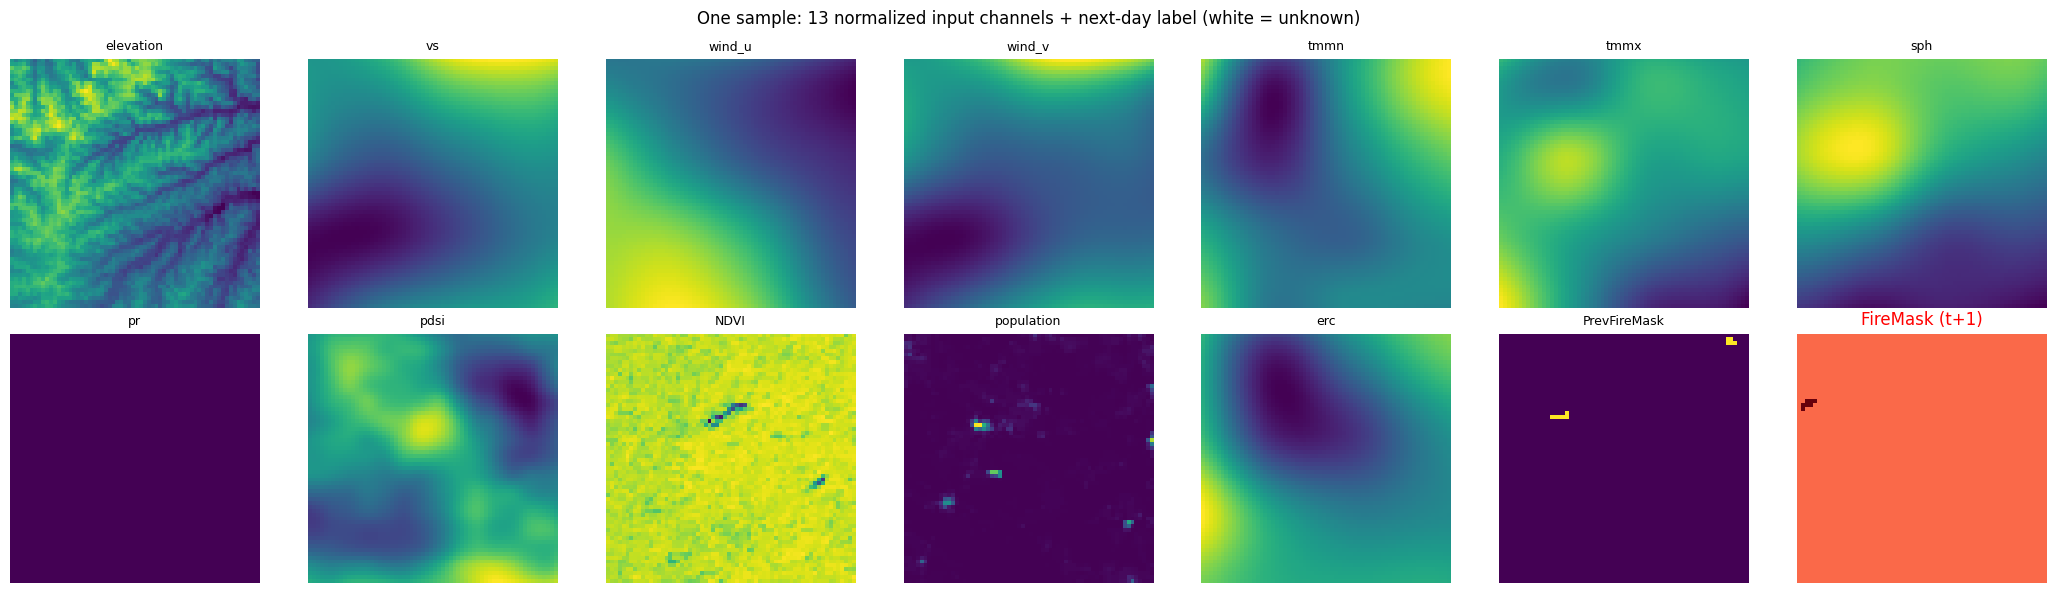

channel value range after normalization: -3.6264960765838623 … 5.111616134643555


In [ ]:
# Visual sanity check of one normalized sample (replaces old cell [14], now on the v3 pipeline)
_fd = next(iter(tf.data.TFRecordDataset(tf.io.gfile.glob(TRAIN_PATTERN)).map(_parse_single_sample)))
_x = transform_features(_fd, FEATURES, STATS).numpy()
fig, axes = plt.subplots(2, 7, figsize=(21, 6))
for i, f in enumerate(FEATURES):
    ax = axes.flat[i]; ax.imshow(_x[..., i], cmap='viridis'); ax.set_title(f, fontsize=9); ax.axis('off')
axes.flat[13].imshow(_fd[LABEL].numpy(), cmap='Reds', vmin=-1, vmax=1)
axes.flat[13].set_title('FireMask (t+1)', color='red'); axes.flat[13].axis('off')
plt.suptitle('One sample: 13 normalized input channels + next-day label (white = unknown)'); plt.tight_layout(); plt.show()
print('channel value range after normalization:', float(_x.min()), '…', float(_x.max()))

---
## 6. Prepare the future-fire prediction target
The target is `FireMask` at **day t+1** (MODIS active fire, 1 km). Unknown pixels (−1) stay −1 and are excluded from
loss and metrics. Note: this is *active fire tomorrow*, not cumulative burned area, so a pixel burning today can be 0 tomorrow.

Training uses random 32×32 crops (augmentation); evaluation uses **full 64×64 tiles**, the size used at inference.
No flips or rotations: they would silently invalidate wind direction (comment kept from old cell [50]).

In [ ]:
def build_dataset(pattern, features, stats, training, engineer=add_wind_uv, crop=None, batch=BATCH_SIZE):
    crop = crop or (TRAIN_CROP if training else EVAL_CROP)
    n = len(features)

    def fn(serialized):
        fd = _parse_single_sample(serialized)
        x = transform_features(fd, features, stats, engineer)
        y = tf.where(tf.math.is_finite(fd[LABEL]), fd[LABEL], -1.0)[..., None]
        xy = tf.concat([x, y], axis=-1)
        if training:
            xy = tf.image.random_crop(xy, [crop, crop, n + 1])
        elif crop < SAMPLE_SIZE:
            o = (SAMPLE_SIZE - crop) // 2
            xy = xy[o:o + crop, o:o + crop, :]
        return xy[..., :n], xy[..., n:]

    ds = tf.data.TFRecordDataset(tf.io.gfile.glob(pattern), num_parallel_reads=tf.data.AUTOTUNE)
    ds = ds.map(fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)


_xb, _yb = next(iter(build_dataset(TRAIN_PATTERN, FEATURES, STATS, training=True)))
print('train batch:', _xb.shape, _yb.shape)
_xb, _yb = next(iter(build_dataset(EVAL_PATTERN, FEATURES, STATS, training=False)))
print('eval batch: ', _xb.shape, _yb.shape)

train batch: (32, 32, 32, 13) (32, 32, 32, 1)
eval batch:  (32, 64, 64, 13) (32, 64, 64, 1)


---
## 7. Train / validation / test split
* **NDWS train / eval / test** files as published. Validation is used for early stopping, threshold choice, calibration,
  and any configuration choice. **Test is evaluated once**, in Section 10, for the frozen configuration.
* Caveat: NDWS records have no coordinates or dates, and the same fire appears on consecutive days. If the published split
  is at the sample level, neighbouring days of one fire can sit in both train and test, so NDWS test scores may be optimistic.
* The leakage-free test is the **event hold-out** (Section 17): the PINN's fire (Palisades, January 2025), which is outside
  the NDWS period (2012–2020) and evaluated at the PINN's held-out overpasses with an identical information cutoff.

---
## 8. U-Net definition
`build_unet` is unchanged from old cell [16]. Called with input `(None, None, C)` it is fully convolutional, so the same weights
run on 32×32 crops and 64×64 tiles (H and W must be multiples of 8). The masked loss and metrics are from old cell [52].

In [ ]:
def build_unet(input_shape=(None, None, len(FEATURES)), num_filters_start=FILTERS):
    """U-Net for pixel-wise next-day fire probability: [H, W, C] → [H, W, 1] (sigmoid)."""
    inputs = layers.Input(shape=input_shape)
    # Encoder
    c1 = layers.Conv2D(num_filters_start, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(num_filters_start, 3, activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.Dropout(0.2)(layers.MaxPooling2D(2)(c1))
    c2 = layers.Conv2D(num_filters_start * 2, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(num_filters_start * 2, 3, activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.Dropout(0.2)(layers.MaxPooling2D(2)(c2))
    c3 = layers.Conv2D(num_filters_start * 4, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(num_filters_start * 4, 3, activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.Dropout(0.3)(layers.MaxPooling2D(2)(c3))
    # Bottleneck
    c4 = layers.Conv2D(num_filters_start * 8, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(num_filters_start * 8, 3, activation='relu', padding='same')(c4)
    c4 = layers.Dropout(0.3)(layers.BatchNormalization()(c4))
    # Decoder with skip connections
    u5 = layers.concatenate([layers.Conv2DTranspose(num_filters_start * 4, 2, strides=2, padding='same')(c4), c3])
    c5 = layers.Conv2D(num_filters_start * 4, 3, activation='relu', padding='same')(u5)
    c5 = layers.BatchNormalization()(layers.Conv2D(num_filters_start * 4, 3, activation='relu', padding='same')(c5))
    u6 = layers.concatenate([layers.Conv2DTranspose(num_filters_start * 2, 2, strides=2, padding='same')(c5), c2])
    c6 = layers.Conv2D(num_filters_start * 2, 3, activation='relu', padding='same')(u6)
    c6 = layers.BatchNormalization()(layers.Conv2D(num_filters_start * 2, 3, activation='relu', padding='same')(c6))
    u7 = layers.concatenate([layers.Conv2DTranspose(num_filters_start, 2, strides=2, padding='same')(c6), c1])
    c7 = layers.Conv2D(num_filters_start, 3, activation='relu', padding='same')(u7)
    c7 = layers.BatchNormalization()(layers.Conv2D(num_filters_start, 3, activation='relu', padding='same')(c7))
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)
    return Model(inputs=[inputs], outputs=[outputs])


def masked_weighted_bce(pos_weight=POS_WEIGHT):
    """BCE over labelled pixels only; fire pixels weighted. Makes outputs uncalibrated → isotonic in 10b."""
    def loss(y_true, y_pred):
        valid = tf.cast(y_true >= 0, tf.float32)
        y = tf.clip_by_value(y_true, 0.0, 1.0)
        p = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        l = -(pos_weight * y * tf.math.log(p) + (1 - y) * tf.math.log(1 - p))
        return tf.reduce_sum(l * valid) / (tf.reduce_sum(valid) + 1e-6)
    return loss


class MaskedAUC(tf.keras.metrics.AUC):
    def update_state(self, y_true, y_pred, sample_weight=None):
        valid = tf.cast(y_true >= 0, y_pred.dtype)
        return super().update_state(tf.clip_by_value(y_true, 0.0, 1.0), y_pred, sample_weight=valid)


def make_model(n_channels, filters=FILTERS, pos_weight=POS_WEIGHT, lr=LR):
    m = build_unet((None, None, n_channels), filters)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=masked_weighted_bce(pos_weight),
              metrics=[MaskedAUC(curve='PR', name='pr_auc'), MaskedAUC(curve='ROC', name='roc_auc')])
    return m


print(f'{len(FEATURES)} input channels, {make_model(len(FEATURES)).count_params():,} parameters')

13 input channels, 1,931,297 parameters


---
## 9. Training
One canonical configuration (13 channels), trained with several seeds. Each run keeps the checkpoint with the best
**validation** PR-AUC; the best seed is chosen on validation. Seed-to-seed spread is reported because it is the noise floor
for every comparison in Section 10 and Appendix A.

*The Keras warning "Your input ran out of data" at the end of epoch 1 is harmless: the dataset length is unknown until then.*

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


def train_one(seed, features, stats, engineer=add_wind_uv, tag='main', epochs=None):
    tf.keras.utils.set_random_seed(seed)
    train_ds = build_dataset(TRAIN_PATTERN, features, stats, True, engineer)
    val_ds   = build_dataset(EVAL_PATTERN, features, stats, False, engineer)
    model = make_model(len(features))
    ckpt = os.path.join(OUTPUT_DIR, f'{tag}_seed{seed}.weights.h5')
    cbs = [ModelCheckpoint(ckpt, monitor='val_pr_auc', mode='max', save_best_only=True, save_weights_only=True),
           EarlyStopping(monitor='val_pr_auc', mode='max', patience=PATIENCE)]
    # shuffle=False only silences a Keras warning: train_ds is already shuffled in build_dataset
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs or EPOCHS, callbacks=cbs, verbose=2,
                     shuffle=False)
    model.load_weights(ckpt)                    # best validation epoch
    return model, hist.history


def load_bundle(bundle_dir=BUNDLE_DIR):
    b = {'model': tf.keras.models.load_model(os.path.join(bundle_dir, 'model.keras'), compile=False),
         'features': json.load(open(os.path.join(bundle_dir, 'features.json'))),
         'stats': {k: tuple(v) for k, v in json.load(open(os.path.join(bundle_dir, 'stats.json'))).items()},
         'calibrator': joblib.load(os.path.join(bundle_dir, 'calibrator.joblib')),
         'thresholds': json.load(open(os.path.join(bundle_dir, 'thresholds.json'))),
         'manifest': json.load(open(os.path.join(bundle_dir, 'manifest.json')))}
    assert b['features'] == FEATURES, 'bundle was trained with a different channel list'
    return b


if RUN_TRAINING:
    RUNS = {}
    for seed in SEEDS:
        print(f'\n══ seed {seed} ══')
        model, hist = train_one(seed, FEATURES, STATS)
        RUNS[seed] = {'model': model, 'history': hist,
                      'best_val_pr_auc': float(np.max(hist['val_pr_auc'])),
                      'best_epoch': int(np.argmax(hist['val_pr_auc']) + 1)}
    seed_table = pd.DataFrame({s: {k: v for k, v in r.items() if k.startswith('best')} for s, r in RUNS.items()}).T
    display(seed_table)
    SEED_STD_VAL_PR_AUC = float(seed_table['best_val_pr_auc'].std()) if len(RUNS) > 1 else float('nan')
    BEST_SEED = int(seed_table['best_val_pr_auc'].idxmax())
    best_model = RUNS[BEST_SEED]['model']
    print(f"Val PR-AUC {seed_table['best_val_pr_auc'].mean():.4f} ± {SEED_STD_VAL_PR_AUC:.4f} "
          f"(mean ± std over seeds); selected seed {BEST_SEED}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for s, r in RUNS.items():
        axes[0].plot(r['history']['val_pr_auc'], marker='o', label=f'seed {s}')
        axes[1].plot(r['history']['loss'], label=f'train, seed {s}')
        axes[1].plot(r['history']['val_loss'], ls='--', label=f'val, seed {s}')
    axes[0].set_title('Validation PR-AUC'); axes[1].set_title('Masked weighted BCE')
    for a in axes: a.set_xlabel('epoch'); a.legend(fontsize=8); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    BUNDLE = load_bundle()
    best_model, STATS = BUNDLE['model'], BUNDLE['stats']
    SEED_STD_VAL_PR_AUC = BUNDLE['manifest'].get('seed_std_val_pr_auc', float('nan'))
    print('Loaded bundle:', BUNDLE['manifest']['created_utc'])

Loaded bundle: 2026-09-29T22:46:11+00:00


---
## 10. Evaluation
**10a — Skill against baselines.** Everything on full 64×64 tiles. Thresholds are chosen on validation and applied to test.

| Baseline | Meaning |
|---|---|
| Persistence | Tomorrow = today. Scores **zero** on new-fire pixels by construction. |
| Dilation 1 px | Today's fire grown by one 1 km cell in every direction (isotropic spread). |
| Distance decay | Score = exp(−distance to today's fire). Pure proximity: the null hypothesis for "spread". |

"New fire" = labelled pixels where `PrevFireMask == 0` (known not burning today). The **new-fire PR-AUC against the distance-decay
baseline** is the test of whether the U-Net predicts spread beyond proximity. It also corresponds to what the frontend's
"+Δ spread risk" layers display.

In [ ]:
def collect(model, ds, prev_idx=PREV_IDX):
    """→ Y, P, PREV, each [N, H, W]."""
    Y, P, PREV = [], [], []
    for x, y in ds:
        P.append(model(x, training=False).numpy()[..., 0])
        Y.append(y.numpy()[..., 0])
        PREV.append(x.numpy()[..., prev_idx])
    return np.concatenate(Y), np.concatenate(P), np.concatenate(PREV)


def best_f1_threshold(y, p):
    m = y >= 0
    prec, rec, thr = precision_recall_curve(y[m], p[m])
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return float(thr[np.argmax(f1[:-1])])


def score(y, p, thr, subset=None, probabilistic=False):
    m = (y >= 0) if subset is None else ((y >= 0) & subset)
    yy, pp = (y[m] == 1), p[m]
    yhat = pp >= thr
    tp, fp, fn = np.sum(yhat & yy), np.sum(yhat & ~yy), np.sum(~yhat & yy)
    prec, rec = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    out = {'n_pos': int(yy.sum()), 'precision': prec, 'recall': rec,
           'f1': 2 * prec * rec / max(prec + rec, 1e-9), 'threshold': thr}
    if len(np.unique(pp)) > 2 and 0 < yy.sum() < yy.size:        # ranking metrics only for continuous scores
        out['pr_auc'] = average_precision_score(yy, pp)
        out['roc_auc'] = roc_auc_score(yy, pp)
    if probabilistic:
        out['brier'] = float(np.mean((pp - yy) ** 2))
    return out


def fire_distance_km(prev, cap=MAX_FIRE_DIST_KM):
    """Euclidean distance (1 px = 1 km) from each pixel to today's nearest fire pixel, per tile."""
    out = np.full(prev.shape, float(cap), np.float32)
    for i in range(len(prev)):
        fire = prev[i] > 0
        if fire.any():
            out[i] = np.minimum(ndimage.distance_transform_edt(~fire), cap)
    return out


def dilation_baseline(prev, px=1):
    return ndimage.binary_dilation(prev > 0, structure=np.ones((1, 2 * px + 1, 2 * px + 1), bool)).astype(np.float32)


val_eval_ds  = build_dataset(EVAL_PATTERN, FEATURES, STATS, training=False)
test_eval_ds = build_dataset(TEST_PATTERN, FEATURES, STATS, training=False)
Yv, Pv, PRv = collect(best_model, val_eval_ds)
Yt, Pt, PRt = collect(best_model, test_eval_ds)          # ← the only use of the test set
print('val', Yv.shape, '| test', Yt.shape)

# Distance decay: any monotone transform ranks identically, so exp(−d / 1 km) suffices for PR-AUC and F1.
Sv_dist, St_dist = np.exp(-fire_distance_km(PRv)), np.exp(-fire_distance_km(PRt))
THR_UNET_RAW = best_f1_threshold(Yv, Pv)
THR_DIST     = best_f1_threshold(Yv, Sv_dist)

candidates = {
    'U-Net':          (Pt, THR_UNET_RAW),
    'Persistence':    ((PRt > 0).astype(np.float32), 0.5),
    'Dilation 1 px':  (dilation_baseline(PRt), 0.5),
    'Distance decay': (St_dist, THR_DIST),
}
NEW_T = PRt == 0
rows = []
for name, (p, thr) in candidates.items():
    for sub_name, sub in [('all', None), ('new fire', NEW_T)]:
        rows.append({'model': name, 'pixels': sub_name, **score(Yt, p, thr, sub)})
EVAL_TABLE = pd.DataFrame(rows)
display(EVAL_TABLE.pivot(index='model', columns='pixels', values=['pr_auc', 'f1', 'precision', 'recall']).round(4))
print('share of tomorrow\'s fire pixels that are new:', f"{NEW_T[(Yt == 1)].mean():.1%}")

_u = EVAL_TABLE.query("model == 'U-Net' and pixels == 'new fire'")['pr_auc'].item()
_d = EVAL_TABLE.query("model == 'Distance decay' and pixels == 'new fire'")['pr_auc'].item()
_noise = SEED_STD_VAL_PR_AUC if np.isfinite(SEED_STD_VAL_PR_AUC) else 0.01
print(f'\nNew-fire PR-AUC: U-Net {_u:.4f} vs distance decay {_d:.4f} (Δ = {_u - _d:+.4f}; seed noise ≈ {_noise:.4f})')
if _u - _d > 2 * _noise:
    print('→ The U-Net predicts new fire beyond proximity alone. "Next-day spread probability" is a supported description.')
else:
    print('→ No evidence of skill beyond proximity. Describe the output as a proximity + fuel/weather prior;\n'
          '  directional spread comes from the PINN in the ensemble.')

val (1877, 64, 64) | test (1689, 64, 64)


pr_auc               f1          precision           recall  \
pixels             all new fire     all new fire       all new fire     all   
model                                                                         
Dilation 1 px      NaN      NaN  0.3278   0.2174    0.2507   0.1786  0.4734   
Distance decay  0.2038   0.1037  0.3278   0.2174    0.2507   0.1786  0.4734   
Persistence        NaN      NaN  0.3093   0.0000    0.3572   0.0000  0.2728   
U-Net           0.2517   0.1442  0.3559   0.2518    0.2800   0.2148  0.4882   

                         
pixels         new fire  
model                    
Dilation 1 px    0.2778  
Distance decay   0.2778  
Persistence      0.0000  
U-Net            0.3041

share of tomorrow's fire pixels that are new: 72.0%

New-fire PR-AUC: U-Net 0.1442 vs distance decay 0.1037 (Δ = +0.0405; seed noise ≈ 0.0027)
→ The U-Net predicts new fire beyond proximity alone. "Next-day spread probability" is a supported description.


**10b — Calibration.** With `pos_weight = 10` the raw sigmoid is not a probability. Isotonic regression is fitted on validation
(method from old cell [60]). The frontend shows `fire_probability` to users (FR-E03) and the ensemble averages it with the
PINN, so calibration is required, not optional. Values are capped at `P_MAX`: on test, the few cells calibrated near 100%
burned only about a quarter of the time.

Test Brier: raw 0.02337 → calibrated 0.01038
Max calibrated probability on test: 0.600


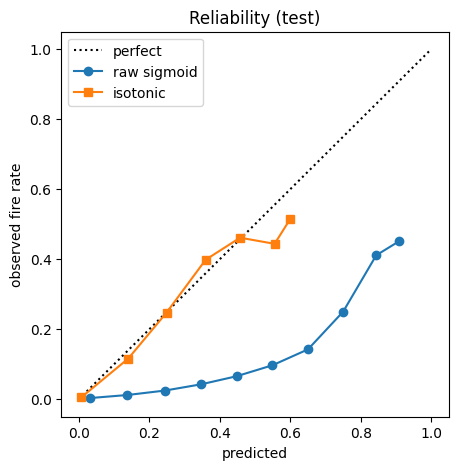

,mean_pred,observed,n
bin,,,
0,0.0070,0.0055,6507475
1,0.1400,0.1160,106581
2,0.2488,0.2474,65649
3,0.3598,0.3985,32415
4,0.4577,0.4615,11467
5,0.5556,0.4440,3881
6,0.6000,0.5152,231


In [ ]:
if RUN_TRAINING:
    m = Yv >= 0
    pv, yv = Pv[m], (Yv[m] == 1).astype(float)
    rng = np.random.default_rng(0)
    pos, neg = np.where(yv == 1)[0], np.where(yv == 0)[0]
    n_neg = min(len(neg), 50 * max(len(pos), 1))
    sel = np.concatenate([pos, rng.choice(neg, size=n_neg, replace=False)])
    w = np.where(yv[sel] == 1, 1.0, len(neg) / n_neg)          # undo negative subsampling
    calibrator = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0).fit(pv[sel], yv[sel], sample_weight=w)
else:
    calibrator = BUNDLE['calibrator']


def calibrate(p):
    """Isotonic calibration, capped at P_MAX (the top isotonic step was over-confident on test)."""
    return np.minimum(calibrator.predict(np.asarray(p, float).ravel()).reshape(np.shape(p)), P_MAX)


Pv_cal, Pt_cal = calibrate(Pv), calibrate(Pt)


def reliability(y, p, bins=10):
    m = y >= 0
    idx = np.clip((p[m] * bins).astype(int), 0, bins - 1)
    return (pd.DataFrame({'bin': idx, 'pred': p[m], 'obs': (y[m] == 1)})
              .groupby('bin').agg(mean_pred=('pred', 'mean'), observed=('obs', 'mean'), n=('obs', 'size')))


rel_raw, rel_cal = reliability(Yt, Pt), reliability(Yt, Pt_cal)
m = Yt >= 0
print(f"Test Brier: raw {np.mean((Pt[m] - (Yt[m] == 1)) ** 2):.5f} → calibrated {np.mean((Pt_cal[m] - (Yt[m] == 1)) ** 2):.5f}")
print(f"Max calibrated probability on test: {Pt_cal[m].max():.3f}")
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k:', label='perfect')
ax.plot(rel_raw.mean_pred, rel_raw.observed, 'o-', label='raw sigmoid')
ax.plot(rel_cal.mean_pred, rel_cal.observed, 's-', label='isotonic')
ax.set_xlabel('predicted'); ax.set_ylabel('observed fire rate'); ax.set_title('Reliability (test)'); ax.legend()
plt.show()
display(rel_cal.round(4))

**10c — Risk-label thresholds.** Fixed 0.30 / 0.60 thresholds meet calibrated probabilities that rarely exceed ~0.55, so
`HIGH_RISK` would almost never appear. In `'validation'` mode:
* `HIGH_RISK` = the best-F1 threshold on calibrated validation probabilities (the operating point routing should avoid);
* `MODERATE_RISK` = the highest threshold that still recalls `MODERATE_TARGET_RECALL` of validation fire pixels.

Probabilities are **not** stretched to fill the scale: `fire_probability` must stay an honest probability.

In [ ]:
def derive_risk_thresholds(y, p_cal, target_recall=MODERATE_TARGET_RECALL):
    m = y >= 0
    prec, rec, thr = precision_recall_curve(y[m] == 1, p_cal[m])
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    high = float(thr[np.argmax(f1[:-1])])
    ok = np.where(rec[:-1] >= target_recall)[0]
    moderate = float(thr[ok.max()]) if len(ok) else float(thr[0])
    moderate = max(moderate, P_EMIT)                 # below P_EMIT cells are not even sent to the map
    if moderate >= high:
        moderate = high / 2
    return {'MODERATE_RISK': moderate, 'HIGH_RISK': high}


def risk_label(p, thr):
    return np.where(p >= thr['HIGH_RISK'], 'HIGH_RISK', np.where(p >= thr['MODERATE_RISK'], 'MODERATE_RISK', 'LOW_RISK'))


if RUN_TRAINING:
    VAL_DERIVED_THRESHOLDS = derive_risk_thresholds(Yv, Pv_cal)
    THRESHOLDS = {'mode': RISK_THRESHOLD_MODE, 'validation': VAL_DERIVED_THRESHOLDS, 'fixed': FIXED_RISK_THRESHOLDS}
else:
    THRESHOLDS = BUNDLE['thresholds']
RISK_THRESHOLDS = dict(THRESHOLDS['validation'] if THRESHOLDS['mode'] == 'validation' else THRESHOLDS['fixed'])
RISK_THRESHOLDS['MODERATE_RISK'] = max(RISK_THRESHOLDS['MODERATE_RISK'], P_EMIT)   # also fixes bundles saved before v3.1
RISK_THRESHOLDS['HIGH_RISK'] = min(RISK_THRESHOLDS['HIGH_RISK'], P_MAX)            # HIGH must stay reachable under the cap
if RISK_THRESHOLDS['MODERATE_RISK'] >= RISK_THRESHOLDS['HIGH_RISK']:                # weak model: keep the order sane
    print(f"⚠️ HIGH threshold {RISK_THRESHOLDS['HIGH_RISK']:.3f} is below the MODERATE floor; MODERATE set to HIGH / 2")
    RISK_THRESHOLDS['MODERATE_RISK'] = RISK_THRESHOLDS['HIGH_RISK'] / 2
print('Active risk thresholds:', {k: round(v, 4) for k, v in RISK_THRESHOLDS.items()}, f"({THRESHOLDS['mode']})")

m = Yt >= 0
rows = []
for mode, thr in [('fixed 0.30 / 0.60', THRESHOLDS['fixed']), ('active (used on the map)', RISK_THRESHOLDS)]:
    lab = risk_label(Pt_cal[m], thr)
    s_high = score(Yt, Pt_cal, thr['HIGH_RISK'])
    s_mod = score(Yt, Pt_cal, thr['MODERATE_RISK'])
    rows.append({'mode': mode, **{f'% {k}': 100 * np.mean(lab == k) for k in ('LOW_RISK', 'MODERATE_RISK', 'HIGH_RISK')},
                 'HIGH precision': s_high['precision'], 'HIGH recall': s_high['recall'],
                 '≥MODERATE recall': s_mod['recall']})
display(pd.DataFrame(rows).set_index('mode').round(3))

TEST_SUMMARY = {sub: score(Yt, Pt_cal, RISK_THRESHOLDS['HIGH_RISK'], s, probabilistic=True)
                for sub, s in [('all', None), ('new_fire', NEW_T)]}
display(pd.DataFrame(TEST_SUMMARY).T.round(4))

Active risk thresholds: {'MODERATE_RISK': 0.05, 'HIGH_RISK': 0.1578} (validation)


,% LOW_RISK,% MODERATE_RISK,% HIGH_RISK,HIGH precision,HIGH recall,≥MODERATE recall
mode,,,,,,
fixed 0.30 / 0.60,99.287,0.710,0.003,0.515,0.001,0.238
active (used on the map),94.728,3.087,2.185,0.280,0.488,0.662


,n_pos,precision,recall,f1,threshold,pr_auc,roc_auc,brier
all,84331.0,0.2800,0.4882,0.3559,0.1578,0.2467,0.8652,0.0104
new_fire,60758.0,0.2148,0.3041,0.2518,0.1578,0.1402,0.8224,0.0084


**10d — Visual check of the model being shipped** (replaces old cell [26], which showed the v1 model).

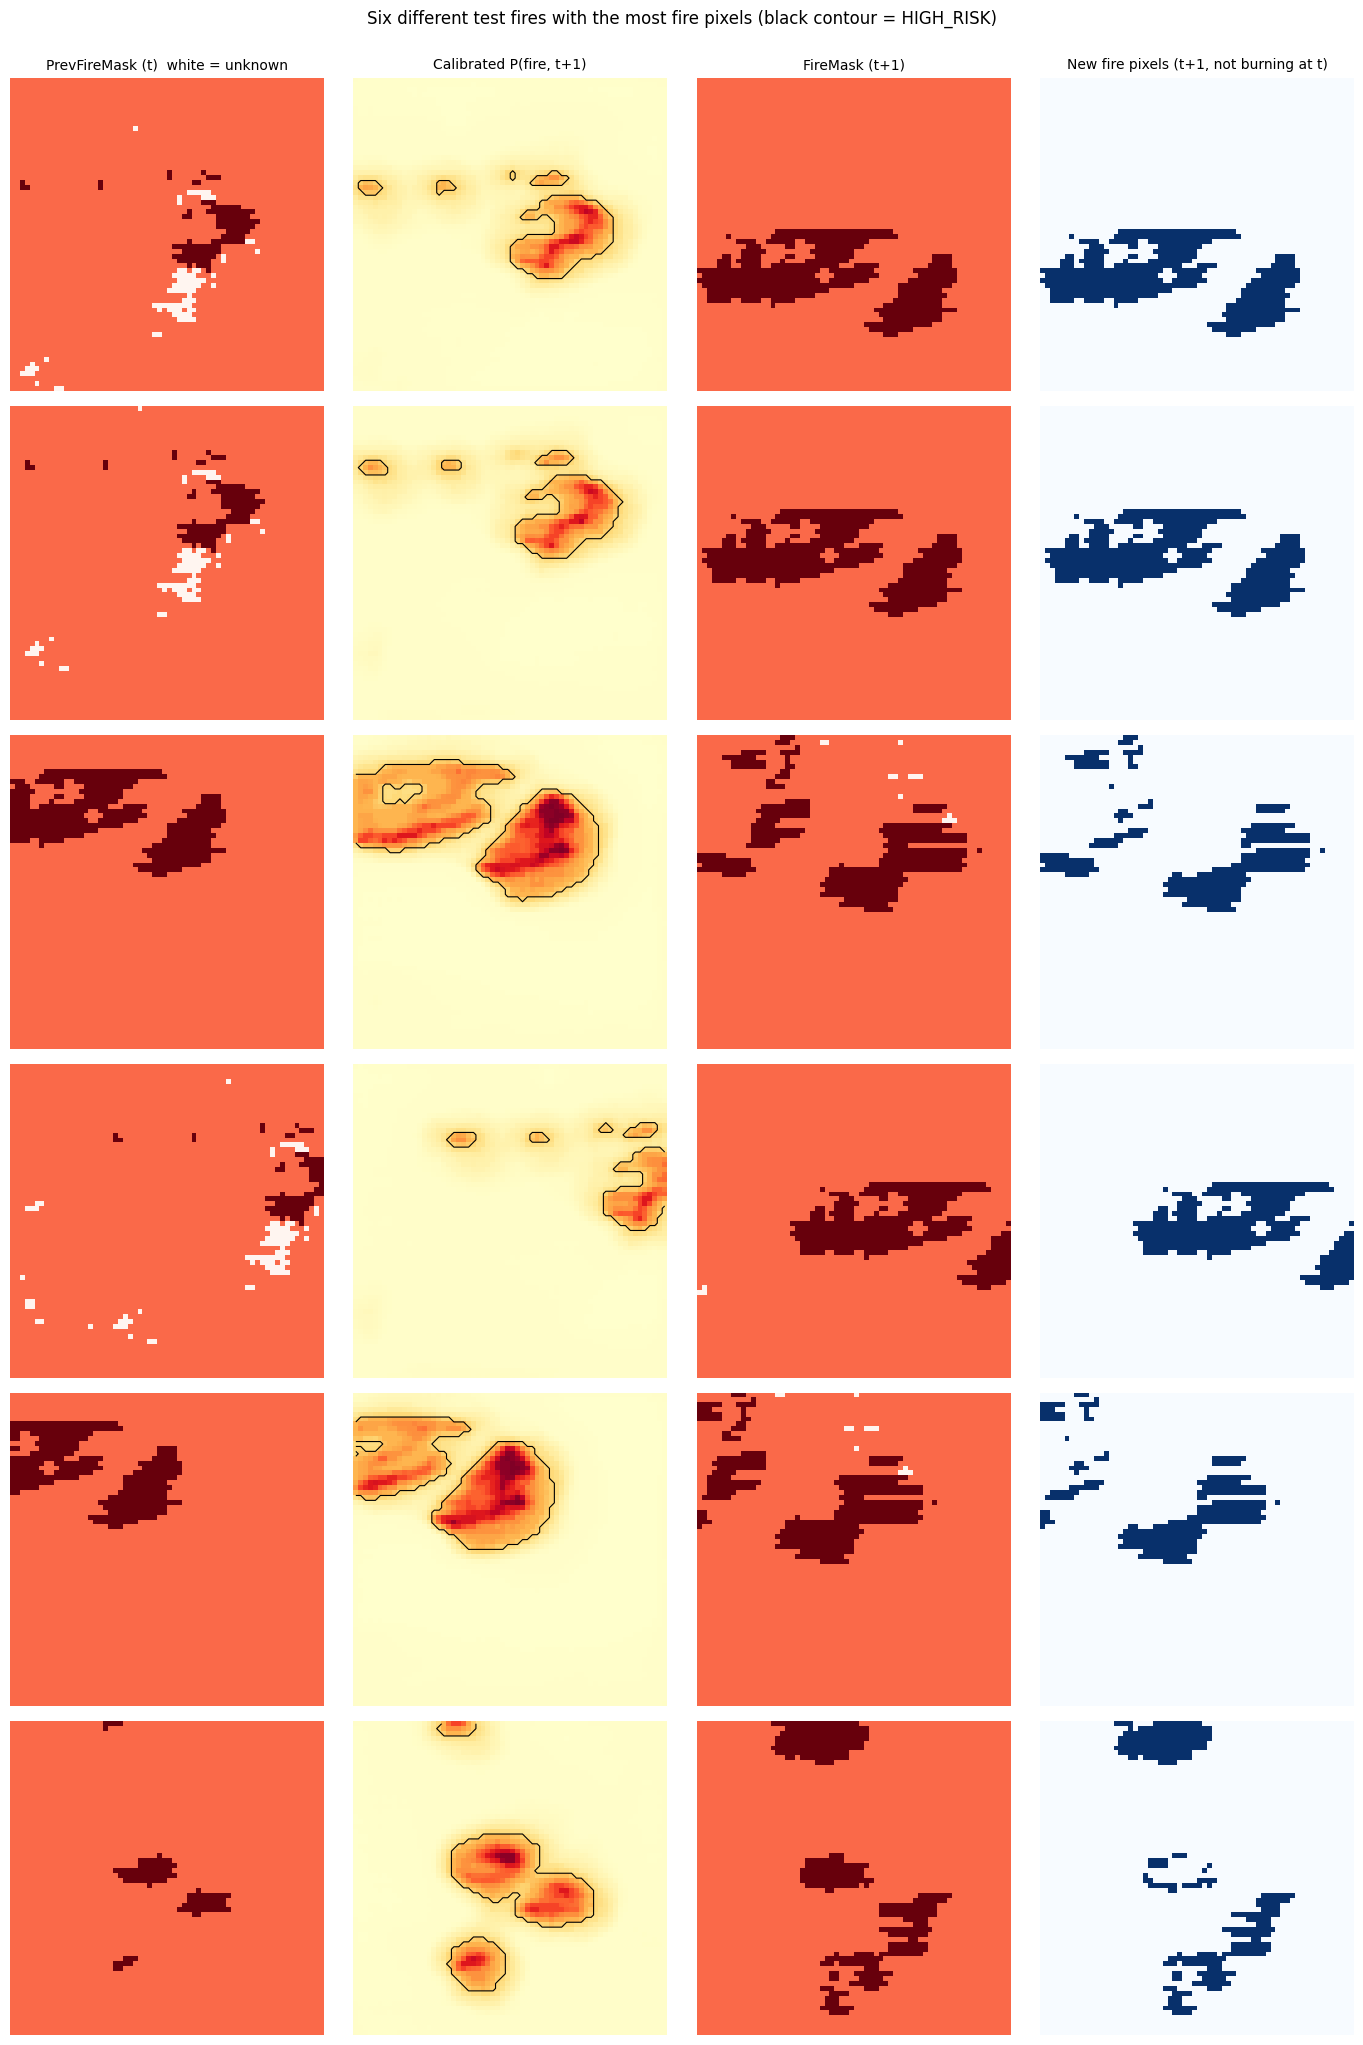

In [ ]:
def distinct_tiles(Y, k=6, max_overlap=0.2):
    """Tiles with the most fire, skipping near-copies of tiles already chosen (NDWS overlaps neighbouring tiles)."""
    chosen = []
    for i in np.argsort(-(Y == 1).sum(axis=(1, 2))):
        fire_i = Y[i] == 1
        if not fire_i.any():
            break
        if all((fire_i & (Y[j] == 1)).sum() / max((fire_i | (Y[j] == 1)).sum(), 1) <= max_overlap for j in chosen) \
                and all(np.abs(PRt[i] - PRt[j]).sum() > 0 for j in chosen):
            chosen.append(i)
        if len(chosen) == k:
            break
    return chosen


order = distinct_tiles(Yt) or [int(np.argmax((Yt == 1).sum(axis=(1, 2))))]
fig, axes = plt.subplots(len(order), 4, figsize=(14, 3.4 * len(order)), squeeze=False)
for r, i in enumerate(order):
    new = (Yt[i] == 1) & (PRt[i] == 0)
    panels = [(PRt[i], 'Reds', -1, 1, 'PrevFireMask (t)  white = unknown'),
              (Pt_cal[i], 'YlOrRd', 0, max(0.05, float(Pt_cal.max())), 'Calibrated P(fire, t+1)'),
              (Yt[i], 'Reds', -1, 1, 'FireMask (t+1)'),
              (new.astype(float), 'Blues', 0, 1, 'New fire pixels (t+1, not burning at t)')]
    for c, (img, cmap, lo, hi, title) in enumerate(panels):
        ax = axes[r, c]; ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi); ax.axis('off')
        if r == 0: ax.set_title(title, fontsize=10)
    axes[r, 1].contour(Pt_cal[i] >= RISK_THRESHOLDS['HIGH_RISK'], levels=[0.5], colors='k', linewidths=0.8)
plt.suptitle('Six different test fires with the most fire pixels (black contour = HIGH_RISK)', y=1.0); plt.tight_layout(); plt.show()

**10e — Save the model bundle.** Everything the inference service needs to rebuild the model: an uncompiled `model.keras`
(load with `compile=False`), channel list, statistics, calibrator, thresholds, and a manifest with versions and metrics.

In [ ]:
if RUN_TRAINING:
    export = build_unet((None, None, len(FEATURES)), FILTERS)       # uncompiled copy: no custom-object issues
    export.set_weights(best_model.get_weights())
    export.save(os.path.join(BUNDLE_DIR, 'model.keras'))
    json.dump(FEATURES, open(os.path.join(BUNDLE_DIR, 'features.json'), 'w'))
    json.dump(STATS, open(os.path.join(BUNDLE_DIR, 'stats.json'), 'w'), indent=1)
    joblib.dump(calibrator, os.path.join(BUNDLE_DIR, 'calibrator.joblib'))
    json.dump(THRESHOLDS, open(os.path.join(BUNDLE_DIR, 'thresholds.json'), 'w'), indent=1)
    manifest = {
        'created_utc': dt.datetime.now(dt.timezone.utc).isoformat(timespec='seconds'),
        'model_version': 'unet-ndws-v3',
        'target': 'calibrated P(active fire in 1 km cell during the next UTC day)',
        'horizon_hours': FORECAST_HORIZON_H, 'resolution_m': RES_M, 'crs': GRID_CRS,
        'lattice': {'x0': LATTICE_X0, 'y0': LATTICE_Y0, 'ncols': LATTICE_NCOLS},
        'features': FEATURES, 'filters': FILTERS, 'pos_weight': POS_WEIGHT,
        'stats_version': STATS_VERSION, 'valid_range': VALID_RANGE,
        'seeds': {int(s): r['best_val_pr_auc'] for s, r in RUNS.items()}, 'selected_seed': BEST_SEED,
        'seed_std_val_pr_auc': SEED_STD_VAL_PR_AUC,
        'test_metrics_at_high_threshold': {k: {kk: float(vv) for kk, vv in v.items()} for k, v in TEST_SUMMARY.items()},
        'tensorflow': tf.__version__,
    }
    json.dump(manifest, open(os.path.join(BUNDLE_DIR, 'manifest.json'), 'w'), indent=1)
    EVAL_TABLE.to_csv(os.path.join(OUTPUT_DIR, 'test_eval_table.csv'), index=False)
    BUNDLE = load_bundle()                                            # round-trip check
    _x, _ = next(iter(test_eval_ds))
    assert np.allclose(BUNDLE['model'](_x[:2]).numpy(), best_model(_x[:2], training=False).numpy(), atol=1e-5)
    print('Bundle saved and verified:', sorted(os.listdir(BUNDLE_DIR)))

---
## 11. Inference on the evaluation event
Runs the bundled model on the PINN's fire with **the same information cutoff as the PINN** (its last training overpass).
The input tile is a lattice-snapped 64×64 km EPSG:3310 tile containing the PINN's 16×26 km domain.

* `PrevFireMask` comes from the **PINN team's QC'd VIIRS detections** when that file exists, so both members see identical
  observations; otherwise from the FIRMS archive. **Training used MODIS 1 km masks**, so the density diagnostic below
  compares the live mask with NDWS tiles.
* Environmental channels: `gee_features` from old cell [64], unchanged apart from taking a `Grid`.
* Detections **after** the cutoff are loaded by a separate function and used only for scoring in Section 17.
* **Industrial heat filter (v3.1).** Satellites flag refineries and gas flares as "fire". FIRMS archive rows with
  `type != 0` are dropped, and cells detected on several days spread over the months *before* the event are masked as
  static heat sources. In the first live run, the only HIGH_RISK cells were the Carson/Wilmington refineries.
* **Confidence range (v3.1).** The three seed models from Section 9 give each cell a `p_low`–`p_high` range (FR-E03).

In [ ]:
BUNDLE = BUNDLE if 'BUNDLE' in globals() else load_bundle()


def _tile_input(bundle, raw):
    fd = {k: tf.constant(np.asarray(v, np.float32)) for k, v in raw.items()}
    return transform_features(fd, bundle['features'], bundle['stats'])[None]


def _calibrated(bundle, p):
    return np.minimum(bundle['calibrator'].predict(p.ravel()).reshape(p.shape), P_MAX)


def predict_tile(bundle, raw):
    """raw: dict of [H, W] arrays in NDWS units (all RAW_INPUTS + PrevFireMask) → calibrated [H, W], capped at P_MAX."""
    p = bundle['model'](_tile_input(bundle, raw), training=False).numpy()[0, :, :, 0]
    return _calibrated(bundle, p)


def load_seed_models(bundle):
    """The per-seed checkpoints from Section 9 (outputs_v3/main_seed*.weights.h5)."""
    models = []
    for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'main_seed*.weights.h5'))):
        m = build_unet((None, None, len(bundle['features'])), FILTERS)
        m.load_weights(path)
        models.append(m)
    return models


def predict_tile_range(bundle, raw, models):
    """Per-cell min / max calibrated probability across seed models → (p_low, p_high).
    The calibrator was fitted on the selected seed, so this is an approximate spread, not a formal interval."""
    x = _tile_input(bundle, raw)
    ps = np.stack([_calibrated(bundle, m(x, training=False).numpy()[0, :, :, 0]) for m in models])
    return ps.min(0), ps.max(0)


# ── Detections ───────────────────────────────────────────────────────────────
FIRMS_ARCHIVE_SOURCES = ['VIIRS_SNPP_SP', 'VIIRS_NOAA20_SP']                       # check names on the FIRMS API page
FIRMS_NRT_SOURCES = ['VIIRS_SNPP_NRT', 'VIIRS_NOAA20_NRT', 'VIIRS_NOAA21_NRT']


def grid_bbox_lonlat(grid, pad_deg=0.05):
    xmin, xmax, ymin, ymax = grid.bounds
    lon, lat = _to_wgs.transform([xmin, xmax, xmax, xmin], [ymin, ymin, ymax, ymax])
    return (min(lon) - pad_deg, min(lat) - pad_deg, max(lon) + pad_deg, max(lat) + pad_deg)


def _with_datetime(df):
    df = df.copy()
    if 'datetime_utc' in df.columns:
        df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], utc=True)
    else:
        t = df['acq_time'].astype(int).astype(str).str.zfill(4)
        df['datetime_utc'] = pd.to_datetime(df['acq_date'].astype(str) + ' ' + t.str[:2] + ':' + t.str[2:], utc=True)
    return df


def fetch_firms(start_day, n_days, bbox, sources):
    """VIIRS detections in bbox for [start_day, start_day + n_days), fetched in ≤5-day chunks."""
    if not FIRMS_MAP_KEY:
        raise RuntimeError('Set FIRMS_MAP_KEY (Section 1) or provide the shared detections CSV.')
    w, s, e, n = bbox
    frames, day = [], pd.Timestamp(start_day)
    end = day + pd.Timedelta(days=n_days)
    while day < end:
        span = min(5, (end - day).days)
        for src in sources:
            url = (f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{FIRMS_MAP_KEY}/{src}/'
                   f'{w},{s},{e},{n}/{span}/{day:%Y-%m-%d}')
            try:
                df = pd.read_csv(url)
                if 'latitude' in df.columns:
                    frames.append(df.assign(source=src))
                else:
                    print(f'{src}: unexpected response {df.columns[:1].tolist()}')
            except Exception as ex:
                print(f'{src}: {ex}')
        day += pd.Timedelta(days=span)
    if not frames:
        return pd.DataFrame(columns=['latitude', 'longitude', 'datetime_utc'])
    df = _with_datetime(pd.concat(frames, ignore_index=True))
    conf = df['confidence'].astype(str).str.lower().str[0]
    return drop_non_vegetation(df[conf != 'l']).reset_index(drop=True)   # low-confidence + industrial rows out


def drop_non_vegetation(df):
    """FIRMS archive `type`: 0 = presumed vegetation fire, 1 = volcano, 2 = static land source (refineries, flares),
    3 = offshore. NRT files have no `type` column; the static-source mask below covers that case."""
    if 'type' in df.columns:
        n = len(df)
        df = df[pd.to_numeric(df['type'], errors='coerce').fillna(0) == 0]
        if n - len(df):
            print(f'dropped {n - len(df)} non-vegetation detections (FIRMS type 1–3)')
    return df


def load_event_detections(event, grid, until):
    """Detections from event start up to `until` (inclusive). Prefers the PINN team's QC'd file."""
    start = pd.Timestamp(event['start_day'], tz='UTC')
    if os.path.exists(event['shared_detections_csv']):
        df = drop_non_vegetation(_with_datetime(pd.read_csv(event['shared_detections_csv'])))
        src = 'shared QC file (PINN pipeline)'
    else:
        n_days = (pd.Timestamp(until).normalize() - start).days + 1
        df, src = fetch_firms(event['start_day'], n_days, grid_bbox_lonlat(grid), FIRMS_ARCHIVE_SOURCES), 'FIRMS archive'
    df = df[(df['datetime_utc'] >= start) & (df['datetime_utc'] <= pd.Timestamp(until))]
    print(f'{len(df)} detections from {src}, {start:%Y-%m-%d} → {pd.Timestamp(until):%Y-%m-%d %H:%M}Z')
    return df.reset_index(drop=True)


def utc_day(df, day):
    return df[df['datetime_utc'].dt.strftime('%Y-%m-%d') == day]


def static_heat_mask(grid, before_day, dets=None):
    """Cells detected on ≥STATIC_MIN_DAYS different days spread over ≥STATIC_MIN_SPAN_DAYS, in the
    STATIC_LOOKBACK_DAYS ending STATIC_GAP_DAYS before `before_day`. Wildfires move on; refineries do not."""
    end = pd.Timestamp(before_day, tz='UTC') - pd.Timedelta(days=STATIC_GAP_DAYS)
    start = end - pd.Timedelta(days=STATIC_LOOKBACK_DAYS)
    if dets is None:
        dets = fetch_firms(start.strftime('%Y-%m-%d'), STATIC_LOOKBACK_DAYS, grid_bbox_lonlat(grid), FIRMS_ARCHIVE_SOURCES)
    dets = dets[(dets['datetime_utc'] >= start) & (dets['datetime_utc'] < end)]
    mask = np.zeros((grid.h, grid.w), bool)
    if len(dets) == 0:
        return mask
    xs, ys = _to_grid.transform(dets['longitude'].to_numpy(), dets['latitude'].to_numpy())
    col = np.floor((xs - grid.x0) / grid.res).astype(int); row = np.floor((grid.y0 - ys) / grid.res).astype(int)
    ok = (row >= 0) & (row < grid.h) & (col >= 0) & (col < grid.w)
    cells = pd.DataFrame({'r': row[ok], 'c': col[ok], 'day': dets['datetime_utc'].dt.normalize().to_numpy()[ok]})
    per_cell = cells.groupby(['r', 'c'])['day'].agg(['nunique', 'min', 'max'])
    static = per_cell[(per_cell['nunique'] >= STATIC_MIN_DAYS) &
                      ((per_cell['max'] - per_cell['min']).dt.days >= STATIC_MIN_SPAN_DAYS)]
    for r, c_ in static.index:
        mask[r, c_] = True
    return mask


# ── Environmental channels (old cell [64]) ───────────────────────────────────
def _ee_latest(collection_id, date, lookback_days, bands=None):
    import ee
    d = ee.Date(date)
    col = ee.ImageCollection(collection_id).filterDate(d.advance(-lookback_days, 'day'), d.advance(1, 'day'))
    img = ee.Image(col.sort('system:time_start', False).first())
    return img.select(bands) if bands else img


def gee_features(grid, date_str):
    """All RAW_INPUTS on `grid` for `date_str` via Earth Engine computePixels. Requires ee.Initialize()."""
    import ee
    gm = _ee_latest('IDAHO_EPSCOR/GRIDMET', date_str, 5, ['tmmn', 'tmmx', 'vs', 'th', 'sph', 'pr', 'erc'])
    print('GRIDMET image date:', ee.Date(gm.get('system:time_start')).format('YYYY-MM-dd').getInfo())
    pdsi = _ee_latest('GRIDMET/DROUGHT', date_str, 15, ['pdsi'])
    ndvi = _ee_latest('NASA/VIIRS/002/VNP13A1', date_str, 40, ['NDVI'])     # verify ID / scale vs the stats table
    elev = ee.Image('USGS/SRTMGL1_003').select(['elevation'])
    pop = (ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density')
             .sort('system:time_start', False).first().select(['population_density'], ['population']))
    stack = ee.Image.cat([elev, gm, pdsi, ndvi, pop]).toFloat()
    arr = ee.data.computePixels({
        'expression': stack, 'fileFormat': 'NUMPY_NDARRAY',
        'grid': {'dimensions': {'width': grid.w, 'height': grid.h},
                 'affineTransform': {'scaleX': grid.res, 'shearX': 0, 'translateX': grid.x0,
                                     'shearY': 0, 'scaleY': -grid.res, 'translateY': grid.y0},
                 'crsCode': GRID_CRS}})
    return {name: np.asarray(arr[name], np.float32) for name in arr.dtype.names}


if RUN_EVENT:
    xmin, xmax, ymin, ymax = EVENT['pinn_bounds']
    EVENT_GRID = Grid.around_xy((xmin + xmax) / 2, (ymin + ymax) / 2)
    gx0, gx1, gy0, gy1 = EVENT_GRID.bounds
    assert gx0 <= xmin and xmax <= gx1 and gy0 <= ymin and ymax <= gy1, 'PINN domain must lie inside the U-Net tile'
    ISSUED_AT   = pd.Timestamp(EVENT['info_cutoff'])
    VALID_START = pd.Timestamp(EVENT['valid_day'], tz='UTC')
    VALID_END   = VALID_START + pd.Timedelta(hours=FORECAST_HORIZON_H)

    if EVENT_INPUT_MODE == 'live':
        import ee
        ee.Initialize(project=EE_PROJECT or None)          # run ee.Authenticate() once beforehand
        DETS_IN = load_event_detections(EVENT, EVENT_GRID, until=ISSUED_AT)
        RAW = gee_features(EVENT_GRID, EVENT['issue_day'])
        RAW['PrevFireMask'] = rasterize_points(utc_day(DETS_IN, EVENT['issue_day']), EVENT_GRID)
        BURNED = rasterize_points(DETS_IN, EVENT_GRID) > 0               # everything observed up to the cutoff
        # Scoring only — after the cutoff, never fed to a model:
        DETS_SCORING = load_event_detections(EVENT, EVENT_GRID, until=VALID_END)
        TRUTH_VALID_DAY = rasterize_points(utc_day(DETS_SCORING, EVENT['valid_day']), EVENT_GRID)
        STATIC = static_heat_mask(EVENT_GRID, EVENT['start_day'])
        print(f'static heat sources masked: {int(STATIC.sum())} cells '
              f'({int((STATIC & BURNED).sum())} of them had "fire" detections during the event)')
        RAW['PrevFireMask'][STATIC] = 0.0
        BURNED &= ~STATIC
        TRUTH_VALID_DAY[STATIC] = 0.0
    else:
        print('DRY RUN: an NDWS test tile placed on the event grid. Interface check only — not a result.')
        _tiles = list(tf.data.TFRecordDataset(tf.io.gfile.glob(TEST_PATTERN)).map(_parse_single_sample).take(300))
        _fd = max(_tiles, key=lambda fd: float(tf.reduce_sum(tf.cast(fd['PrevFireMask'] > 0, tf.float32))))
        RAW = {k: _fd[k].numpy() for k in NDWS_INPUTS}
        BURNED = RAW['PrevFireMask'] > 0
        TRUTH_VALID_DAY = (_fd[LABEL].numpy() == 1).astype(np.float32)

    P_UNET = predict_tile(BUNDLE, RAW)
    SEED_MODELS = load_seed_models(BUNDLE) if SEED_RANGE else []
    if len(SEED_MODELS) >= 2:
        P_LOW, P_HIGH = predict_tile_range(BUNDLE, RAW, SEED_MODELS)
        print(f'confidence range from {len(SEED_MODELS)} seed models: median width '
              f'{np.median((P_HIGH - P_LOW)[P_UNET >= P_EMIT]) if (P_UNET >= P_EMIT).any() else 0:.3f} on cells ≥ P_EMIT')
    else:
        P_LOW = P_HIGH = None
        print('seed range skipped (needs ≥2 main_seed*.weights.h5 in outputs_v3)')
    _ndws = [(t > 0).sum() for t in PRv if (t > 0).any()]
    print(f"PrevFireMask fire cells: {int((RAW['PrevFireMask'] > 0).sum())} "
          f"(NDWS validation tiles with fire: median {np.median(_ndws):.0f}, 90th pct {np.percentile(_ndws, 90):.0f})")
    print(f'U-Net: max calibrated p = {P_UNET.max():.3f}; cells ≥ HIGH = {(P_UNET >= RISK_THRESHOLDS["HIGH_RISK"]).sum()}')

dropped 144 non-vegetation detections (FIRMS type 1–3)
1733 detections from FIRMS archive, 2025-01-07 → 2025-01-10 21:48Z
GRIDMET image date: 2025-01-10
dropped 179 non-vegetation detections (FIRMS type 1–3)
2106 detections from FIRMS archive, 2025-01-07 → 2025-01-12 00:00Z
dropped 960 non-vegetation detections (FIRMS type 1–3)
static heat sources masked: 2 cells (0 of them had "fire" detections during the event)
confidence range from 3 seed models: median width 0.035 on cells ≥ P_EMIT
PrevFireMask fire cells: 35 (NDWS validation tiles with fire: median 9, 90th pct 131)
U-Net: max calibrated p = 0.220; cells ≥ HIGH = 11


---
## 12. Produce the probability raster (U-Net output contract)
This is the "UNet-shaped raster fixture" the PINN report asks for. It is written as NetCDF to match the PINN's `palisades_*.nc` artifacts:
`fire_probability[y, x]` (float32, NaN = nodata) on 1 km EPSG:3310 cell centres, plus `grid_id`, with issue, valid, and cutoff times in the attributes.

In [ ]:
def export_unet_netcdf(p, grid, path, issued_at, valid_start, valid_end, extra_attrs=None):
    import xarray as xr
    X, Y = grid.centers()
    ds = xr.Dataset(
        {'fire_probability': (('y', 'x'), np.asarray(p, np.float32),
                              {'long_name': 'calibrated P(active fire in 1 km cell during valid window)', 'units': '1'}),
         'grid_id': (('y', 'x'), grid.grid_ids().astype(np.int32))},
        coords={'x': ('x', X[0, :], {'units': 'm', 'axis': 'X'}), 'y': ('y', Y[:, 0], {'units': 'm', 'axis': 'Y'})})
    ds.attrs.update({
        'crs': GRID_CRS, 'crs_wkt': CRS.from_user_input(GRID_CRS).to_wkt(), 'resolution_m': grid.res,
        'lattice_x0': LATTICE_X0, 'lattice_y0': LATTICE_Y0, 'lattice_ncols': LATTICE_NCOLS,
        'issued_at': pd.Timestamp(issued_at).isoformat(), 'info_cutoff': pd.Timestamp(issued_at).isoformat(),
        'valid_start': pd.Timestamp(valid_start).isoformat(), 'valid_end': pd.Timestamp(valid_end).isoformat(),
        'horizon_hours': FORECAST_HORIZON_H, 'model_version': BUNDLE['manifest']['model_version'],
        'feature_list': ','.join(BUNDLE['features']), **(extra_attrs or {})})
    ds.to_netcdf(path)
    return path


if RUN_EVENT:
    UNET_NC = export_unet_netcdf(P_UNET, EVENT_GRID,
                                 os.path.join(OUTPUT_DIR, f"unet_prob_{EVENT['name']}_{ISSUED_AT:%Y%m%dT%H%MZ}.nc"),
                                 ISSUED_AT, VALID_START, VALID_END, {'input_mode': EVENT_INPUT_MODE})
    print('Wrote', UNET_NC)

Wrote /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/unet_prob_Palisades_20250110T2148Z.nc


---
## 13. Interface with the PINN and ensemble
The PINN outputs a signed distance Φ (front at Φ = 0); the U-Net outputs a probability. Conversion:
`p_pinn = mean over 3×3 sub-points of σ(−Φ_m / s)`, which is the expected fraction of each 1 km cell inside the predicted front.
The PINN is a coordinate network, so it is queried directly at sub-cell points; no raster reprojection is needed.

Fusion is a **linear pool of calibrated probabilities** with a fixed weight (`W_UNET`). Where the PINN has no value
(outside its domain, or no PINN run yet for this fire) the U-Net is used alone.

Normalization assumed by `load_pinn_phi`, consistent with the report's PDE `Φ_τ + (R_eff·T/L)‖∇Φ‖ = 0`:
τ = t / T, x_n = (x − x0) / L, y_n = (y − y0) / L, Φ_m = L · Φ_n. **CONFIRM x0, y0, L, the sign, and the checkpoint format.**

In [ ]:
def pinn_prob(phi_m, grid, t_valid, s_m, k=3, inside_negative=True, bounds=None):
    """phi_m(x[N], y[N], t_utc) → metres. Returns [h, w] probability; NaN outside `bounds`."""
    X, Y = grid.centers()
    off = ((np.arange(k) + 0.5) / k - 0.5) * grid.res
    xs = np.broadcast_to(X[..., None, None] + off[None, None, None, :], X.shape + (k, k))
    ys = np.broadcast_to(Y[..., None, None] - off[None, None, :, None], X.shape + (k, k))
    phi = np.asarray(phi_m(xs.ravel(), ys.ravel(), t_valid), float).reshape(xs.shape)
    z = (-phi if inside_negative else phi) / s_m
    p = (1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))).mean(axis=(-2, -1))
    if bounds is not None:
        xmin, xmax, ymin, ymax = bounds
        p[~((X >= xmin) & (X <= xmax) & (Y >= ymin) & (Y <= ymax))] = np.nan
    return p


def fuse(p_unet, p_pinn=None, w_unet=W_UNET, nonburnable=None):
    p = np.asarray(p_unet, float).copy()
    if p_pinn is not None:
        both = np.isfinite(p_pinn) & np.isfinite(p)
        p[both] = w_unet * p[both] + (1.0 - w_unet) * p_pinn[both]
    if nonburnable is not None:
        p[nonburnable] = 0.0
    return np.clip(p, 0.0, 1.0)


def load_pinn_phi(cfg):
    """Teammate's level-set network → phi_m(x, y, t_utc) in metres, or None if not available/configured."""
    missing = [k for k in ('x0', 'y0', 'L_m') if cfg[k] is None]
    if not os.path.exists(cfg['checkpoint']) or missing:
        print(f"PINN unavailable (checkpoint exists: {os.path.exists(cfg['checkpoint'])}; unset: {missing}) → U-Net only")
        return None
    import torch, torch.nn as nn
    try:
        obj = torch.load(cfg['checkpoint'], map_location='cpu', weights_only=False)
    except TypeError:
        obj = torch.load(cfg['checkpoint'], map_location='cpu')
    if isinstance(obj, nn.Module):
        net = obj
    else:
        state = obj.get('state_dict', obj.get('model', obj)) if isinstance(obj, dict) else obj
        mods, d = [], 3
        for _ in range(cfg['layers']):
            mods += [nn.Linear(d, cfg['hidden']), nn.Tanh()]
            d = cfg['hidden']
        net = nn.Sequential(*mods, nn.Linear(d, 1))
        try:
            net.load_state_dict(state)
        except RuntimeError:
            # Different module names (e.g. 'layers.0.weight' in a custom class): load Linear layers in order,
            # checking every shape. If this also fails, ask the PINN owner for their loader.
            lin = [mod for mod in net if isinstance(mod, nn.Linear)]
            ws = [v for k, v in state.items() if k.endswith('weight')]
            bs = [v for k, v in state.items() if k.endswith('bias')]
            assert len(ws) == len(bs) == len(lin), f'{len(ws)} weight tensors vs {len(lin)} Linear layers'
            with torch.no_grad():
                for mod, w_, b_ in zip(lin, ws, bs):
                    assert tuple(mod.weight.shape) == tuple(w_.shape), (mod.weight.shape, w_.shape)
                    mod.weight.copy_(w_); mod.bias.copy_(b_)
            print('PINN weights loaded by layer order (key names differed)')
    net.eval()
    t0 = pd.Timestamp(cfg['t_origin_utc'])

    def phi_m(x, y, t_utc):
        tau = (pd.Timestamp(t_utc) - t0).total_seconds() / 86400.0 / cfg['T_days']
        inp = np.stack([np.full(np.shape(x), tau), (np.asarray(x) - cfg['x0']) / cfg['L_m'],
                        (np.asarray(y) - cfg['y0']) / cfg['L_m']], axis=-1).astype(np.float32)
        with torch.no_grad():
            return cfg['L_m'] * net(torch.from_numpy(inp)).numpy()[:, 0]
    return phi_m


def synthetic_pinn_phi(burned, grid, t_issue, speed_m_per_day=2000.0):
    """DRY RUN ONLY: a circle around today's fire expanding at a fixed speed (phi < 0 inside)."""
    X, Y = grid.centers()
    cx, cy = X[burned].mean(), Y[burned].mean()
    r0 = math.sqrt(burned.sum() / math.pi) * grid.res

    def phi_m(x, y, t_utc):
        days = (pd.Timestamp(t_utc) - pd.Timestamp(t_issue)).total_seconds() / 86400.0
        return np.hypot(np.asarray(x) - cx, np.asarray(y) - cy) - (r0 + speed_m_per_day * days)
    return phi_m


FBFM40_NONBURNABLE = {91, 92, 93, 98, 99}    # urban, snow/ice, agriculture, water, barren


def load_nonburnable_mask(cfg, grid, min_burnable_frac=0.1):
    """Aggregate the PINN stack's 90 m FBFM40 codes to the 1 km grid. None if the stack is unavailable."""
    if not os.path.exists(cfg['stack_nc']):
        print('No PINN stack → no non-burnable mask')
        return None
    import xarray as xr
    ds = xr.open_dataset(cfg['stack_nc'])
    fuel = ds[cfg['fuel_var']]                                   # CONFIRM variable and coord names ('x', 'y')
    xx, yy = np.meshgrid(ds['x'].values, ds['y'].values)
    col = np.floor((xx - grid.x0) / grid.res).astype(int); row = np.floor((grid.y0 - yy) / grid.res).astype(int)
    ok = (row >= 0) & (row < grid.h) & (col >= 0) & (col < grid.w)
    burnable = ~np.isin(fuel.values.astype(int), list(FBFM40_NONBURNABLE))
    tot, brn = np.zeros((grid.h, grid.w)), np.zeros((grid.h, grid.w))
    np.add.at(tot, (row[ok], col[ok]), 1); np.add.at(brn, (row[ok], col[ok]), burnable[ok])
    return (tot > 0) & (brn / np.maximum(tot, 1) < min_burnable_frac)


if RUN_EVENT:
    if EVENT_INPUT_MODE == 'dry_run':
        PHI, PINN_BOUNDS = synthetic_pinn_phi(BURNED, EVENT_GRID, ISSUED_AT), None
    else:
        PHI, PINN_BOUNDS = load_pinn_phi(PINN_CFG), EVENT['pinn_bounds']
    P_PINN = (pinn_prob(PHI, EVENT_GRID, VALID_END, PINN_CFG['s_m'], k=3,
                        inside_negative=PINN_CFG['inside_negative'], bounds=PINN_BOUNDS) if PHI else None)
    NONBURNABLE = load_nonburnable_mask(PINN_CFG, EVENT_GRID) if EVENT_INPUT_MODE == 'live' else None
    P_ENS = fuse(P_UNET, P_PINN, W_UNET, NONBURNABLE)
    print('members:', 'U-Net' + (' + PINN' if P_PINN is not None else ' only'),
          f'| max p_ens = {P_ENS.max():.3f}')

PINN unavailable (checkpoint exists: False; unset: ['x0', 'y0', 'L_m']) → U-Net only
No PINN stack → no non-burnable mask
members: U-Net only | max p_ens = 0.220


---
## 14. Convert ensemble predictions to the geographic grid
The ensemble grid **is** the GeoJSON grid (1 km lattice), so no aggregation choice is left: U-Net cells map 1:1 and PINN cells
are already sub-sampled means. Cell (row r, col c) spans x ∈ [x0 + c·1000, x0 + (c+1)·1000] and y ∈ [y0 − (r+1)·1000, y0 − r·1000];
`grid_id = (lattice row) · 1000 + (lattice col)`.

In [ ]:
if RUN_EVENT:
    ids = EVENT_GRID.grid_ids()
    corners = {'NW': (0, 0), 'NE': (0, EVENT_GRID.w - 1), 'SW': (EVENT_GRID.h - 1, 0), 'SE': (EVENT_GRID.h - 1, EVENT_GRID.w - 1)}
    display(pd.DataFrame([{'corner': k, 'row': r, 'col': c, 'grid_id': int(ids[r, c]),
                           'center lon/lat': tuple(round(v, 5) for v in grid_id_to_center_lonlat(ids[r, c]))}
                          for k, (r, c) in corners.items()]))
    if P_PINN is not None:
        print(f'PINN covers {np.isfinite(P_PINN).sum()} of {P_PINN.size} cells')

,corner,row,col,grid_id,center lon/lat
0,NW,0,0,885531,"(-118.89626, 34.36123)"
1,NE,0,63,885594,"(-118.21131, 34.35257)"
2,SW,63,0,948531,"(-118.90418, 33.79335)"
3,SE,63,63,948594,"(-118.22414, 33.78475)"


---
## 15. Assign risk labels
Thresholds come from the bundle (Section 10c; mode set in Section 1). Cells already burning at the issue time are labelled
`ACTIVE_FIRE` rather than averaged: there the U-Net means "still burning" and the PINN means "inside the perimeter".
The `ACTIVE_FIRE` label needs frontend agreement.

In [ ]:
if RUN_EVENT:
    _lab = risk_label(P_ENS, RISK_THRESHOLDS)
    _lab = np.where(BURNED, 'ACTIVE_FIRE', _lab)
    print('thresholds:', {k: round(v, 4) for k, v in RISK_THRESHOLDS.items()})
    display(pd.Series(_lab.ravel()).value_counts().rename('cells').to_frame())

thresholds: {'MODERATE_RISK': 0.05, 'HIGH_RISK': 0.1578}


,cells
LOW_RISK,3944
ACTIVE_FIRE,140
MODERATE_RISK,12


---
## 16. Export GeoJSON
RFC 7946: WGS84 lon/lat, counter-clockwise exterior rings, no `crs` member. Only cells with p ≥ `P_EMIT` (plus active-fire cells)
are emitted. `timestamp` = issue time. `valid_time` and `horizon_hours` are added as FeatureCollection members
(permitted by RFC 7946). **The meaning of `timestamp` needs frontend agreement.**
`p_low` / `p_high` give the range of `fire_probability` across the three U-Net seed models (FR-E03 "confidence").
They are an approximate spread, not a formal statistical interval.

In [ ]:
def to_geojson(p, grid, timestamp, thr, p_emit=P_EMIT, burned=None, extra_layers=None, collection_props=None, ndp=6):
    p = np.asarray(p, float)
    burned = np.zeros(p.shape, bool) if burned is None else np.asarray(burned, bool)
    ids, labels = grid.grid_ids(), risk_label(np.nan_to_num(p), thr)
    cx = grid.x0 + np.arange(grid.w + 1) * grid.res
    cy = grid.y0 - np.arange(grid.h + 1) * grid.res
    LON, LAT = _to_wgs.transform(*np.meshgrid(cx, cy))
    LON, LAT = np.round(LON, ndp), np.round(LAT, ndp)
    feats = []
    rows, cols = np.where((np.isfinite(p) & (p >= p_emit)) | burned)
    for r, c in zip(rows.tolist(), cols.tolist()):
        ring = [[LON[r + 1, c], LAT[r + 1, c]], [LON[r + 1, c + 1], LAT[r + 1, c + 1]],     # SW → SE
                [LON[r, c + 1], LAT[r, c + 1]], [LON[r, c], LAT[r, c]],                     # → NE → NW
                [LON[r + 1, c], LAT[r + 1, c]]]                                             # → SW (closed, CCW)
        props = ({'grid_id': int(ids[r, c]), 'fire_probability': 1.0, 'risk_label': 'ACTIVE_FIRE'} if burned[r, c] else
                 {'grid_id': int(ids[r, c]), 'fire_probability': round(float(p[r, c]), 3), 'risk_label': str(labels[r, c])})
        for name, layer in (extra_layers or {}).items():
            if layer is not None:
                v = layer[r, c]
                props[name] = None if not np.isfinite(v) else round(float(v), 3)
        feats.append({'type': 'Feature', 'properties': props,
                      'geometry': {'type': 'Polygon', 'coordinates': [[[float(a), float(b)] for a, b in ring]]}})
    fc = {'type': 'FeatureCollection', 'timestamp': timestamp}
    fc.update(collection_props or {})
    fc['features'] = feats
    return fc


def validate_feature_collection(fc):
    allowed = {'LOW_RISK', 'MODERATE_RISK', 'HIGH_RISK', 'ACTIVE_FIRE'}
    ids = [f['properties']['grid_id'] for f in fc['features']]
    assert len(ids) == len(set(ids)), 'duplicate grid_id'
    for f in fc['features']:
        ring = f['geometry']['coordinates'][0]
        assert len(ring) == 5 and ring[0] == ring[-1], 'ring not closed'
        area2 = sum(x1 * y2 - x2 * y1 for (x1, y1), (x2, y2) in zip(ring[:-1], ring[1:]))
        assert area2 > 0, 'ring not counter-clockwise'
        assert all(-180 <= x <= 180 and -90 <= y <= 90 for x, y in ring), 'not lon/lat'
        pr = f['properties']
        assert 0.0 <= pr['fire_probability'] <= 1.0 and pr['risk_label'] in allowed
    json.dumps(fc)                                              # serializable (no numpy types)
    return True


if RUN_EVENT:
    FC = to_geojson(P_ENS, EVENT_GRID, ISSUED_AT.strftime('%Y-%m-%dT%H:%M:%SZ'), RISK_THRESHOLDS, burned=BURNED,
                    extra_layers={'p_unet': P_UNET, 'p_pinn': P_PINN,
                                  # range of fire_probability across U-Net seeds, passed through the same fusion
                                  'p_low': fuse(P_LOW, P_PINN, W_UNET, NONBURNABLE) if P_LOW is not None else None,
                                  'p_high': fuse(P_HIGH, P_PINN, W_UNET, NONBURNABLE) if P_HIGH is not None else None},
                    collection_props={'valid_time': VALID_END.strftime('%Y-%m-%dT%H:%M:%SZ'),
                                      'valid_start': VALID_START.strftime('%Y-%m-%dT%H:%M:%SZ'),
                                      'horizon_hours': FORECAST_HORIZON_H,
                                      'model_version': BUNDLE['manifest']['model_version'],
                                      'members': ['unet'] + (['pinn'] if P_PINN is not None else []),
                                      'w_unet': W_UNET, 'risk_thresholds': RISK_THRESHOLDS,
                                      'input_mode': EVENT_INPUT_MODE})
    validate_feature_collection(FC)
    GEOJSON_PATH = os.path.join(OUTPUT_DIR, f"{EVENT['name']}_{EVENT['valid_day']}_h{FORECAST_HORIZON_H}.geojson")
    json.dump(FC, open(GEOJSON_PATH, 'w'))
    print(f"{len(FC['features'])} features, {os.path.getsize(GEOJSON_PATH) / 1024:.0f} KB → {GEOJSON_PATH}")
    print(json.dumps(FC['features'][0], indent=1)[:600])

152 features, 51 KB → /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/Palisades_2025-01-11_h24.geojson
{
 "type": "Feature",
 "properties": {
  "grid_id": 887568,
  "fire_probability": 1.0,
  "risk_label": "ACTIVE_FIRE",
  "p_unet": 0.006,
  "p_low": 0.006,
  "p_high": 0.006
 },
 "geometry": {
  "type": "Polygon",
  "coordinates": [
   [
    [
     -118.499835,
     34.334184
    ],
    [
     -118.488966,
     34.334041
    ],
    [
     -118.488793,
     34.343052
    ],
    [
     -118.499663,
     34.343195
    ],
    [
     -118.499835,
     34.334184
    ]
   ]
  ]
 }
}


---
## 17. Visual validation and event scoring
**Primary event metric** (shared with the PINN report): mean distance in metres from predicted front points to the observed
boundary at each held-out overpass. "No contour" counts as a failure, not zero. Front masks are compared on the same 1 km grid:
* U-Net and ensemble: burned-so-far ∪ (p ≥ `HIGH_RISK`), with the U-Net's day-level probability used at every overpass of the valid day.
* PINN: p_pinn ≥ 0.5 (Φ ≤ 0), evaluated at each overpass time.

The PINN team reports the same metric at 90 m, so these 1 km numbers are for comparing members with one another.

No observed perimeter for [Timestamp('2025-01-11 10:10:00+0000', tz='UTC'), Timestamp('2025-01-11 19:49:00+0000', tz='UTC'), Timestamp('2025-01-11 21:29:00+0000', tz='UTC')] → check perimeter_time_prop / file


,member,pixels,n_pos,precision,recall,f1,pr_auc
0,U-Net,all,43,0.727,0.186,0.296,0.490
1,U-Net,new fire,28,0.000,0.000,0.000,0.305
2,Ensemble,all,43,0.727,0.186,0.296,0.490
3,Ensemble,new fire,28,0.000,0.000,0.000,0.305


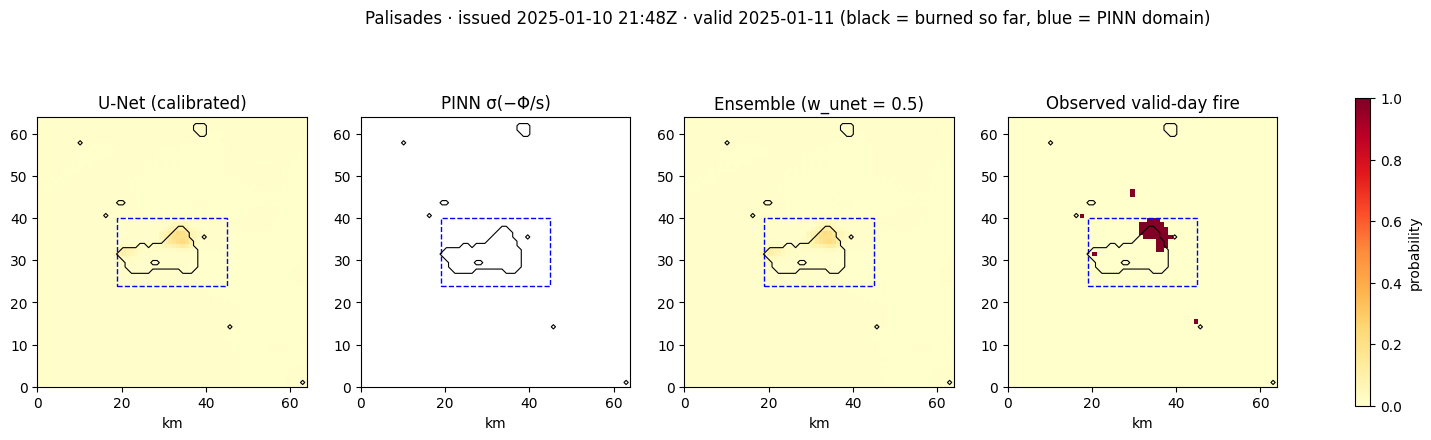

In [ ]:
def densify(ring_xy, step_m=100.0):
    pts = []
    for (x1, y1), (x2, y2) in zip(ring_xy[:-1], ring_xy[1:]):
        n = max(1, int(math.hypot(x2 - x1, y2 - y1) // step_m))
        t = np.arange(n) / n
        pts.append(np.c_[x1 + t * (x2 - x1), y1 + t * (y2 - y1)])
    return np.vstack(pts)


def observed_boundaries(event):
    """{UTC time: [N, 2] boundary points in EPSG:3310} from the PINN's perimeter GeoJSON."""
    if not os.path.exists(event['perimeters_geojson']):
        return {}
    out = {}
    for f in json.load(open(event['perimeters_geojson']))['features']:
        t = pd.Timestamp(f['properties'][event['perimeter_time_prop']])
        t = t.tz_localize('UTC') if t.tzinfo is None else t.tz_convert('UTC')
        g = f['geometry']
        polys = [g['coordinates']] if g['type'] == 'Polygon' else g['coordinates']
        pts = []
        for poly in polys:
            ring = np.asarray(poly[0], float)
            if np.abs(ring).max() <= 180:                       # lon/lat → EPSG:3310
                ring = np.c_[_to_grid.transform(ring[:, 0], ring[:, 1])]
            pts.append(densify(ring))
        out[t] = np.vstack(pts)
    return out


def mask_boundary_points(mask, grid):
    """Centres of mask cells with at least one 4-neighbour outside the mask."""
    m = np.pad(mask, 1, constant_values=False)
    edge = mask & ~(m[:-2, 1:-1] & m[2:, 1:-1] & m[1:-1, :-2] & m[1:-1, 2:])
    X, Y = grid.centers()
    return np.c_[X[edge], Y[edge]]


def front_distance_m(mask, grid, obs_pts):
    pred = mask_boundary_points(np.asarray(mask, bool), grid)
    if len(pred) == 0 or len(obs_pts) == 0:
        return np.nan                                           # "no contour" → failure
    return float(cKDTree(obs_pts).query(pred)[0].mean())


if RUN_EVENT:
    HIGH = RISK_THRESHOLDS['HIGH_RISK']
    if EVENT_INPUT_MODE == 'live':
        obs = observed_boundaries(EVENT)
        targets = [pd.Timestamp(t) for t in EVENT['held_out_overpasses']]
        missing = [t for t in targets if t not in obs]
        if missing:
            print('No observed perimeter for', missing, '→ check perimeter_time_prop / file')
    else:
        obs = {VALID_END: mask_boundary_points(TRUTH_VALID_DAY > 0, EVENT_GRID)}    # dry run: NDWS label as "observed"
        targets = [VALID_END]
    rows = []
    for t in targets:
        if t not in obs:
            continue
        p_pinn_t = (pinn_prob(PHI, EVENT_GRID, t, PINN_CFG['s_m'], inside_negative=PINN_CFG['inside_negative'],
                              bounds=PINN_BOUNDS) if PHI else None)
        masks = {'U-Net': BURNED | (P_UNET >= HIGH)}
        if p_pinn_t is not None:
            masks['PINN'] = np.nan_to_num(p_pinn_t) >= 0.5
            masks['Ensemble'] = BURNED | (fuse(P_UNET, p_pinn_t, W_UNET) >= HIGH)
        masks['Persistence (burned so far)'] = BURNED.copy()
        for name, msk in masks.items():
            rows.append({'overpass': t.strftime('%Y-%m-%d %H:%MZ'), 'member': name,
                         'mean front distance (m)': front_distance_m(msk, EVENT_GRID, obs[t]), 'cells': int(msk.sum())})
    EVENT_SCORES = pd.DataFrame(rows)
    if len(EVENT_SCORES):
        display(EVENT_SCORES.pivot(index='overpass', columns='member', values='mean front distance (m)').round(0))
        EVENT_SCORES.to_csv(os.path.join(OUTPUT_DIR, f"event_scores_{EVENT['name']}.csv"), index=False)

    # Supplementary pixel scores against valid-day detections (not used for any tuning)
    y_px = TRUTH_VALID_DAY.astype(float)
    new_px = RAW['PrevFireMask'] == 0
    px = [{'member': n, 'pixels': s, **score(y_px, p, HIGH, sub)}
          for n, p in [('U-Net', P_UNET), ('Ensemble', P_ENS)] for s, sub in [('all', None), ('new fire', new_px)]]
    display(pd.DataFrame(px)[['member', 'pixels', 'n_pos', 'precision', 'recall', 'f1'] +
                             [c for c in ('pr_auc',) if c in pd.DataFrame(px)]].round(3))

    km = lambda v: (v - EVENT_GRID.x0) / 1000
    ext = [0, EVENT_GRID.w, 0, EVENT_GRID.h]
    panels = [(P_UNET, 'U-Net (calibrated)'), (P_PINN if P_PINN is not None else np.full(P_UNET.shape, np.nan), 'PINN σ(−Φ/s)'),
              (P_ENS, f'Ensemble (w_unet = {W_UNET})'), (TRUTH_VALID_DAY, 'Observed valid-day fire')]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (img, title) in zip(axes, panels):
        im = ax.imshow(img, cmap='YlOrRd', vmin=0, vmax=1, extent=ext)
        ax.contour(np.flipud(BURNED), levels=[0.5], colors='k', linewidths=0.8, extent=ext)
        if PINN_BOUNDS is not None:
            bx0, bx1, by0, by1 = PINN_BOUNDS
            ax.add_patch(plt.Rectangle((km(bx0), (by0 - EVENT_GRID.y0) / 1000 + EVENT_GRID.h), (bx1 - bx0) / 1000,
                                       (by1 - by0) / 1000, fill=False, ec='b', ls='--'))
        ax.set_title(title); ax.set_xlabel('km')
    fig.colorbar(im, ax=axes, shrink=0.8, label='probability')
    plt.suptitle(f"{EVENT['name']} · issued {ISSUED_AT:%Y-%m-%d %H:%MZ} · valid {EVENT['valid_day']} "
                 f"(black = burned so far, blue = PINN domain){' · DRY RUN' if EVENT_INPUT_MODE == 'dry_run' else ''}")
    plt.show()

---
# Part B — GOES hourly model (+1 / +3 / +6 h) and live fire layer

The daily model cannot produce the frontend's +1/+3/+6 h layers: it learned "today → tomorrow" from daily data.
Part B trains the **same U-Net** on hourly samples built from **GOES-West fire detections** (every 10 min, 2 km) and
**RTMA hourly weather** (2.5 km), then runs it live from **NOAA's public GOES-18 bucket on AWS**.

| | Training (Section 19) | Live / event forecast (Sections 18, 21) |
|---|---|---|
| Fire detections | Earth Engine `NOAA/GOES/17/FDCC` (to 2023-01-04), `NOAA/GOES/18/FDCC` (after) | `s3://noaa-goes18/ABI-L2-FDCC` over HTTPS, no account |
| Weather | Earth Engine `NOAA/NWS/RTMA` (hourly analysis) | Open-Meteo hourly, 9×9 points interpolated (no key) |
| Terrain / vegetation | SRTM, VIIRS NDVI (Earth Engine) | same |
| Fires | MTBS California fires ≥ 20,000 acres, 2019–2024 | the event (Palisades) or any fire you point it at |

Earth Engine lags real time by days, which is why live inputs come from AWS and Open-Meteo instead.
Two train/serve differences to keep in mind: weather comes from RTMA in training but Open-Meteo live, and GOES pixels
are resampled by Earth Engine in training but by this notebook live (same nearest-pixel rule).

---
## 18. GOES-18 from NOAA's AWS bucket + "Current Fire Detection" layer
Reads the GOES-18 Fire/Hot Spot product (`ABI-L2-FDCC`) straight from `noaa-goes18` over anonymous HTTPS, maps each
2 km GOES pixel onto the 1 km lattice (nearest pixel, like Earth Engine), and converts fire-mask codes to confidence.
The **current fire layer** is every cell with confidence ≥ 0.5 in the last hour: that is what the frontend legend calls
"Current Fire Detection". It needs no model and no login.

In [ ]:
# [DEFS 18] GOES helpers shared by Sections 18-21
FIRE_CODES = [10, 30, 11, 31, 12, 32, 13, 33, 14, 34, 15, 35]          # fire categories in the GOES fire mask
FIRE_CONF  = [1.0, 1.0, 0.9, 0.9, 0.8, 0.8, 0.5, 0.5, 0.3, 0.3, 0.1, 0.1]  # confidence per category
FIRE_THRESHOLD = 0.5                                                      # ≥ high-probability fire
_CONF_LUT = np.zeros(256, np.float32)
for _code, _conf in zip(FIRE_CODES, FIRE_CONF):
    _CONF_LUT[_code] = _conf
_S3_NS = {'s3': 'http://s3.amazonaws.com/doc/2006-03-01/'}
_GOES_INDEX_CACHE = {}


def _utc(t):
    t = pd.Timestamp(t)
    return t.tz_localize('UTC') if t.tzinfo is None else t.tz_convert('UTC')


def mask_to_conf(mask):
    m = np.clip(np.nan_to_num(np.asarray(mask, float), nan=0.0), 0, 255).astype(int)
    return _CONF_LUT[m]


def _s3_list_keys(bucket, prefix):
    """All object keys under prefix in a public S3 bucket (anonymous REST call, paginated)."""
    keys, token = [], None
    while True:
        params = {'list-type': '2', 'prefix': prefix}
        if token:
            params['continuation-token'] = token
        r = requests.get(f'https://{bucket}.s3.amazonaws.com/', params=params, timeout=60)
        r.raise_for_status()
        root = ET.fromstring(r.content)
        keys += [e.text for e in root.findall('s3:Contents/s3:Key', _S3_NS)]
        if root.findtext('s3:IsTruncated', default='false', namespaces=_S3_NS) != 'true':
            return keys
        token = root.findtext('s3:NextContinuationToken', namespaces=_S3_NS)


def _s3_download(bucket, key):
    dest = os.path.join(GOES_CACHE, os.path.basename(key))
    if not os.path.exists(dest):
        r = requests.get(f'https://{bucket}.s3.amazonaws.com/{key}', timeout=120)
        r.raise_for_status()
        with open(dest + '.part', 'wb') as f:
            f.write(r.content)
        os.replace(dest + '.part', dest)
    return dest


def goes_keys_for_hour(t_hour):
    """GOES files whose scan starts in this UTC hour (every GOES_FILE_STRIDE-th 5-min scan)."""
    t = _utc(t_hour)
    prefix = f'{GOES_PRODUCT}/{t:%Y}/{t.dayofyear:03d}/{t:%H}/'
    return sorted(k for k in _s3_list_keys(GOES_BUCKET, prefix) if k.endswith('.nc'))[::GOES_FILE_STRIDE]


def _goes_indices(ds, grid):
    """Row/col of the GOES pixel containing each grid-cell centre (cached per grid and file geometry)."""
    import xarray as xr
    p = ds['goes_imager_projection'].attrs
    h, lon0 = float(p['perspective_point_height']), float(p['longitude_of_projection_origin'])
    x, y = ds['x'].values.astype(float), ds['y'].values.astype(float)       # scan angles, radians
    key = (grid, h, lon0, x[0], x[-1], len(x), y[0], y[-1], len(y))
    if key not in _GOES_INDEX_CACHE:
        geos = CRS.from_proj4(f"+proj=geos +h={h} +lon_0={lon0} +sweep={p.get('sweep_angle_axis', 'x')} "
                              f"+a={float(p['semi_major_axis'])} +b={float(p['semi_minor_axis'])} +units=m +no_defs")
        X, Y = grid.centers()
        gx, gy = Transformer.from_crs(GRID_CRS, geos, always_xy=True).transform(X, Y)
        ix = np.rint((np.asarray(gx) / h - x[0]) / (x[1] - x[0]))
        iy = np.rint((np.asarray(gy) / h - y[0]) / (y[1] - y[0]))
        ok = np.isfinite(ix) & np.isfinite(iy) & (ix >= 0) & (ix < len(x)) & (iy >= 0) & (iy < len(y))
        _GOES_INDEX_CACHE[key] = (np.where(ok, iy, 0).astype(int), np.where(ok, ix, 0).astype(int), ok)
    return _GOES_INDEX_CACHE[key]


def read_fdc_on_grid(path, grid):
    """One GOES FDC file → (fire confidence, clear look 0/1, FRP in MW) on the grid."""
    import xarray as xr
    with xr.open_dataset(path) as ds:
        iy, ix, ok = _goes_indices(ds, grid)
        mask, dqf, power = ds['Mask'].values, ds['DQF'].values, ds['Power'].values
    conf = np.where(ok, mask_to_conf(mask[iy, ix]), 0.0)
    d = np.asarray(dqf[iy, ix], float)
    clear = ok & np.isfinite(d) & (d <= 1)                  # DQF 0 = good fire, 1 = good fire-free land
    frp = np.where(ok, np.nan_to_num(np.asarray(power[iy, ix], float), nan=0.0), 0.0)
    return conf.astype(np.float32), clear.astype(np.float32), frp.astype(np.float32)


def goes_aws_hourly(grid, t0, n_hours):
    """Per-hour max confidence, number of clear looks and max FRP over [t0, t0 + n_hours) → three [h, w, n] arrays."""
    t0 = _utc(t0).floor('h')
    conf = np.zeros((grid.h, grid.w, n_hours), np.float32)
    nval, frp = np.zeros_like(conf), np.zeros_like(conf)
    for k in range(n_hours):
        keys = goes_keys_for_hour(t0 + pd.Timedelta(hours=k))
        for key in keys:
            c, v, f = read_fdc_on_grid(_s3_download(GOES_BUCKET, key), grid)
            conf[..., k] = np.maximum(conf[..., k], c)
            nval[..., k] += v
            frp[..., k] = np.maximum(frp[..., k], f)
        if not keys:
            print(f'  no GOES files for {t0 + pd.Timedelta(hours=k):%Y-%m-%d %H}Z')
    return conf, nval, frp


def current_fire_geojson(grid, t_end, hours=1):
    """GOES-18 'Current Fire Detection' layer for the frontend: cells with fire confidence ≥ 0.5 in [t_end - hours, t_end)."""
    t_end = _utc(t_end)
    conf, _, frp = goes_aws_hourly(grid, t_end - pd.Timedelta(hours=hours), hours)
    c, f = conf.max(-1), frp.max(-1)
    return to_geojson(np.zeros_like(c), grid, t_end.strftime('%Y-%m-%dT%H:%M:%SZ'), RISK_THRESHOLDS, p_emit=2.0,
                      burned=c >= FIRE_THRESHOLD, extra_layers={'fire_confidence': c, 'frp_mw': f},
                      collection_props={'layer': 'current_fire_detection', 'source': f'GOES-18 {GOES_PRODUCT}',
                                        'window_start': (t_end - pd.Timedelta(hours=hours)).strftime('%Y-%m-%dT%H:%M:%SZ'),
                                        'window_end': t_end.strftime('%Y-%m-%dT%H:%M:%SZ')})

In [ ]:
# Time and place for Part B: the event cutoff (a past time you can check) or 'now' for live use
GOES_T = (pd.Timestamp.now('UTC').floor('h') if GOES_TIME == 'now'
          else _utc(GOES_TIME).floor('h') if GOES_TIME is not None
          else _utc(EVENT['info_cutoff']).floor('h'))       # 21:48Z cutoff → use hours ending 21:00Z (no later data)
if GOES_CENTER is not None:
    GOES_GRID = Grid.around(*GOES_CENTER, size=GOES_TILE)
else:
    _b = EVENT['pinn_bounds']
    GOES_GRID = Grid.around_xy((_b[0] + _b[1]) / 2, (_b[2] + _b[3]) / 2, size=GOES_TILE)
print('GOES time:', GOES_T, '| tile:', GOES_GRID)

if RUN_GOES_CURRENT_FIRE:
    try:
        FC_CURRENT = current_fire_geojson(GOES_GRID, GOES_T, hours=1)
        validate_feature_collection(FC_CURRENT)
        CURRENT_PATH = os.path.join(OUTPUT_DIR, f'current_fire_goes18_{GOES_T:%Y%m%dT%H}Z.geojson')
        json.dump(FC_CURRENT, open(CURRENT_PATH, 'w'))
        print(f"{len(FC_CURRENT['features'])} GOES-18 fire cells in the hour before {GOES_T:%Y-%m-%d %H}Z → {CURRENT_PATH}")
    except requests.RequestException as ex:
        print('NOAA bucket not reachable:', ex)

GOES time: 2025-01-10 21:00:00+00:00 | tile: Grid(x0=85000.0, y0=-389000.0, h=96, w=96, res=1000.0)
53 GOES-18 fire cells in the hour before 2025-01-10 21Z → /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/current_fire_goes18_20250110T21Z.geojson


---
## 19. Build the hourly training set (Earth Engine, one-off)
For each MTBS California fire (≥ `GOES_MIN_ACRES`, `GOES_YEARS`, the `GOES_MAX_PER_YEAR` largest per year), a 96×96 km tile
is centred on the burned area and one sample is written every `GOES_STEP_H` hours while GOES sees fire:

* **Inputs (12 channels):** fire in the last hour (0/1), fire confidence 1–4 h ago, fire confidence in the last 24 h,
  temperature, relative humidity, wind u/v, gust, 1-h precipitation, elevation, slope, NDVI.
* **Labels:** fire detected in the next 1, 3 and 6 hours (1), clearly observed without fire (0), never clearly
  observed because of cloud or smoke (−1, masked like NDWS unknowns).

Samples go to `GOES_DATA_DIR` on Drive as `.npz`. The build **resumes**: finished fires are skipped, so a Colab disconnect
only loses the fire in progress. Expect roughly 2–5 minutes per fire.

In [ ]:
# [DEFS 19] Earth Engine builders
GOES_WEST = [('NOAA/GOES/17/FDCC', '2019-01-01', '2023-01-04'),
             ('NOAA/GOES/18/FDCC', '2023-01-04', '2100-01-01')]
RTMA_BANDS = ['TMP', 'DPT', 'UGRD', 'VGRD', 'GUST', 'ACPC01']
GOES_CHANNELS = ['fire_now', 'fire_prev3h', 'fire_24h', 'tmp_c', 'rh', 'wind_u', 'wind_v', 'gust', 'precip',
                 'elevation', 'slope', 'NDVI']
GOES_FIRE_CHANNELS = 3              # channels 0-2 are fire masks/confidences and are not normalized
GOES_CHUNK_H = 24


def _pixels(img, grid):
    arr = ee.data.computePixels({
        'expression': img.toFloat(), 'fileFormat': 'NUMPY_NDARRAY',
        'grid': {'dimensions': {'width': grid.w, 'height': grid.h},
                 'affineTransform': {'scaleX': grid.res, 'shearX': 0, 'translateX': grid.x0,
                                     'shearY': 0, 'scaleY': -grid.res, 'translateY': grid.y0},
                 'crsCode': GRID_CRS}})
    return {n: np.asarray(arr[n], np.float32) for n in arr.dtype.names}


def _goes_collection(start, end):
    cols = [ee.ImageCollection(cid).filterDate(max(start, s), min(end, e))
            for cid, s, e in GOES_WEST if start < e and end > s]
    out = cols[0]
    for c_ in cols[1:]:
        out = out.merge(c_)
    return out


def goes_ee_hourly(grid, t0, n_hours):
    """Training-time twin of goes_aws_hourly: per-hour max confidence and clear looks from Earth Engine."""
    conf, nval = [], []
    t0 = _utc(t0).floor('h')
    for c0 in range(0, n_hours, GOES_CHUNK_H):
        n = min(GOES_CHUNK_H, n_hours - c0)
        start = t0 + pd.Timedelta(hours=c0)
        fmt = lambda t: t.strftime('%Y-%m-%dT%H:%M:%S')
        coll = _goes_collection(fmt(start), fmt(start + pd.Timedelta(hours=n)))
        e0 = ee.Date(fmt(start))

        def one_hour(i):
            s = e0.advance(i, 'hour')
            col = coll.filterDate(s, s.advance(1, 'hour'))
            empty = col.size().eq(0)
            cf = ee.Image(ee.Algorithms.If(empty, ee.Image.constant(0),
                                           col.map(lambda im: im.select('Mask').remap(FIRE_CODES, FIRE_CONF, 0)).max()))
            vl = ee.Image(ee.Algorithms.If(empty, ee.Image.constant(0),
                                           col.map(lambda im: im.select('DQF').lte(1)).sum()))
            return cf.rename('conf').unmask(0).addBands(vl.rename('nvalid').unmask(0)).toFloat()

        px = _pixels(ee.ImageCollection(ee.List.sequence(0, n - 1).map(one_hour)).toBands(), grid)
        conf += [px[f'{i}_conf'] for i in range(n)]
        nval += [px[f'{i}_nvalid'] for i in range(n)]
    return np.stack(conf, -1), np.stack(nval, -1)


def rtma_at(grid, t):
    e = ee.Date(_utc(t).strftime('%Y-%m-%dT%H:%M:%S'))
    img = (ee.ImageCollection('NOAA/NWS/RTMA').filterDate(e.advance(-2, 'hour'), e.advance(1, 'minute'))
             .sort('system:time_start', False).first())
    return _pixels(ee.Image(img).select(RTMA_BANDS), grid)


def static_layers(grid, date):
    dem = ee.Image('USGS/SRTMGL1_003')
    d = ee.Date(_utc(date).strftime('%Y-%m-%d'))
    ndvi = (ee.ImageCollection('NASA/VIIRS/002/VNP13A1').filterDate(d.advance(-40, 'day'), d)
              .sort('system:time_start', False).first())
    return _pixels(ee.Image.cat([dem.select('elevation'), ee.Terrain.slope(dem).rename('slope'),
                                 ee.Image(ndvi).select('NDVI')]), grid)


def relative_humidity(t_c, td_c):
    return np.clip(100.0 * np.exp(17.625 * td_c / (243.04 + td_c)) / np.exp(17.625 * t_c / (243.04 + t_c)), 0, 100)


def window(conf, nval, a, b):
    return conf[..., a:b].max(-1), nval[..., a:b].sum(-1)


def make_label(conf_w, nval_w):
    return np.where(conf_w >= FIRE_THRESHOLD, 1.0, np.where(nval_w > 0, 0.0, -1.0)).astype(np.float32)


def goes_inputs(conf, nval, k, weather, static):
    """12-channel input for issue hour index k of an hourly stack (hour k-1 is 'the last hour')."""
    now_c, _ = window(conf, nval, k - 1, k)
    prev_c, _ = window(conf, nval, max(k - 4, 0), k - 1)
    day_c, _ = window(conf, nval, max(k - 24, 0), k)
    w = weather
    x = np.stack([(now_c >= FIRE_THRESHOLD).astype(np.float32), prev_c, day_c,
                  w['TMP'], relative_humidity(w['TMP'], w['DPT']), w['UGRD'], w['VGRD'], w['GUST'], w['ACPC01'],
                  static['elevation'], static['slope'], static['NDVI']], -1)
    return x.astype(np.float32)


def samples_for_event(conf, nval, t_start, weather_fn, static, step_h=GOES_STEP_H, horizons=GOES_HORIZONS_H):
    """Yield (t, X, {h: Y}) from an hourly stack that starts 24 h before t_start."""
    for k in range(24, conf.shape[-1] - max(horizons), step_h):
        if (window(conf, nval, k - 1, k)[0] >= FIRE_THRESHOLD).sum() == 0:
            continue                                          # nothing burning in the last hour
        t = _utc(t_start) + pd.Timedelta(hours=k - 24)
        try:
            w = weather_fn(t)
        except Exception as ex:
            print(f'  skip {t:%Y-%m-%d %H}Z: weather unavailable ({str(ex)[:60]})')
            continue
        yield t, goes_inputs(conf, nval, k, w, static), {h: make_label(*window(conf, nval, k, k + h)) for h in horizons}


def _parse_mtbs_date(v):
    v = int(v)
    return (pd.to_datetime(str(v), format='%Y%m%d', utc=True) if 19840101 <= v <= 21001231
            else pd.to_datetime(v, unit='ms', utc=True))


def mtbs_fire_list():
    """California MTBS fires ≥ GOES_MIN_ACRES in GOES_YEARS, the GOES_MAX_PER_YEAR largest per year."""
    ca = ee.Geometry.Rectangle(list(CA_BBOX))
    fc = (ee.FeatureCollection('USFS/GTAC/MTBS/burned_area_boundaries/v1').filterBounds(ca)
            .filter(ee.Filter.gte('BurnBndAc', GOES_MIN_ACRES))
            .map(lambda f: ee.Feature(f.geometry().centroid(100),
                                      {'name': f.get('Incid_Name'), 'ig': f.get('Ig_Date'), 'acres': f.get('BurnBndAc')})))
    rows = []
    for f in fc.getInfo()['features']:
        p, (lon, lat) = f['properties'], f['geometry']['coordinates']
        start = _parse_mtbs_date(p['ig'])
        if GOES_YEARS[0] <= start.year <= GOES_YEARS[1]:
            rows.append({'name': f"{re.sub(r'[^A-Za-z0-9]+', '_', str(p['name'])).strip('_')}_{start.year}",
                         'lat': lat, 'lon': lon, 'start_utc': start, 'acres': p['acres'], 'year': start.year})
    df = pd.DataFrame(rows).drop_duplicates('name')
    df = df.sort_values('acres', ascending=False).groupby('year').head(GOES_MAX_PER_YEAR).sort_values('start_utc')
    df['end_utc'] = df['start_utc'] + pd.Timedelta(days=GOES_EVENT_DAYS)
    return df.reset_index(drop=True)


def build_event(name, lat, lon, start_utc, end_utc, out_dir):
    done = os.path.join(out_dir, f'{name}.done')
    if os.path.exists(done):
        return 0
    grid = Grid.around(lat, lon, size=GOES_TILE)
    t0 = _utc(start_utc) - pd.Timedelta(hours=24)
    n_hours = int((_utc(end_utc) - t0) / pd.Timedelta(hours=1)) + max(GOES_HORIZONS_H)
    conf, nval = goes_ee_hourly(grid, t0, n_hours)
    static = static_layers(grid, start_utc)
    n = 0
    for t, x, ys in samples_for_event(conf, nval, start_utc, lambda t: rtma_at(grid, t), static):
        np.savez_compressed(os.path.join(out_dir, f'{name}_{t:%Y%m%dT%H}.npz'), x=x, fire=name, t=t.isoformat(),
                            **{f'y_h{h}': y for h, y in ys.items()})
        n += 1
    open(done, 'w').write(str(n))
    return n


def load_goes_samples(out_dir, horizon_h):
    """→ X [N, H, W, 12], Y [N, H, W, 1], fire name and issue time per sample."""
    files = sorted(glob.glob(os.path.join(out_dir, '*.npz')))
    if not files:
        raise FileNotFoundError(f'No GOES samples in {out_dir}: run Section 19 (RUN_GOES_BUILD = True) first')
    X, Y, F, T = [], [], [], []
    for f in files:
        d = np.load(f)
        X.append(d['x']); Y.append(d[f'y_h{horizon_h}'][..., None]); F.append(str(d['fire'])); T.append(str(d['t']))
    return np.stack(X), np.stack(Y), np.array(F), pd.to_datetime(T, utc=True)

In [ ]:
if RUN_GOES_BUILD:
    os.makedirs(GOES_DATA_DIR, exist_ok=True)
    FIRES = mtbs_fire_list()
    FIRES.to_csv(os.path.join(GOES_DATA_DIR, 'fires.csv'), index=False)
    display(FIRES[['name', 'start_utc', 'acres', 'lat', 'lon']])
    for r in FIRES.itertuples():
        try:
            n = build_event(r.name, r.lat, r.lon, r.start_utc, r.end_utc, GOES_DATA_DIR)
            print(f'{r.name}: {n} samples')
        except Exception as ex:                  # one bad fire must not stop a multi-hour build
            print(f'{r.name}: FAILED ({str(ex)[:120]}) — rerun later, finished fires are skipped')
    print('samples on Drive:', len(glob.glob(os.path.join(GOES_DATA_DIR, '*.npz'))))

---
## 20. Train the +1 / +3 / +6 h models
One model per horizon, same U-Net, masked loss, isotonic calibration, P_MAX cap and threshold rules as Part A.
* **Split by whole fires, in time order:** the most recent 20% of fires are the test set, the 15% before them are
  validation. Consecutive hours of one fire are near-copies, so a random split would leak.
* **Baselines** as in Section 10, using channel 0 (fire in the last hour) as "today's fire".
* Each horizon is saved as its own bundle in `unet_bundle_v3/goes_h{1,3,6}/`.

In [ ]:
# [DEFS 20]
def chrono_fire_split(F, T, val_frac=0.15, test_frac=0.20):
    first = pd.Series(T, index=F).groupby(level=0).min().sort_values()
    fires = list(first.index)
    assert len(fires) >= 3, f'Only {len(fires)} fires with samples: need at least 3 for train / val / test'
    n_test = max(1, int(round(test_frac * len(fires))))
    n_val = max(1, int(round(val_frac * len(fires))))
    test_f, val_f = fires[-n_test:], fires[-(n_test + n_val):-n_test]
    return ~np.isin(F, test_f + val_f), np.isin(F, val_f), np.isin(F, test_f), val_f, test_f


def goes_norm_stats(X):
    """Per-channel mean/std over training samples; fire channels stay as they are."""
    mu = np.nanmean(X, axis=(0, 1, 2)); sd = np.maximum(np.nanstd(X, axis=(0, 1, 2)), 1e-3)
    mu[:GOES_FIRE_CHANNELS], sd[:GOES_FIRE_CHANNELS] = 0.0, 1.0
    return mu.astype(np.float32), sd.astype(np.float32)


def goes_normalize(X, mu, sd):
    """z-score with a ±10 clip, so one out-of-range live input (e.g. unusual weather) cannot saturate the model."""
    z = np.nan_to_num((X - mu) / sd, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(z, -10.0, 10.0).astype(np.float32)


def goes_tf_dataset(X, Y, training, batch=16):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        c = X.shape[-1]
        ds = ds.shuffle(len(X)).map(
            lambda x, y: tuple(tf.split(tf.image.random_crop(tf.concat([x, y], -1), [TRAIN_CROP, TRAIN_CROP, c + 1]),
                                        [c, 1], axis=-1)), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)


def fit_isotonic(Y, P):
    m = Y >= 0
    p, y = P[m], (Y[m] == 1).astype(float)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    n_neg = min(len(neg), 50 * max(len(pos), 1))
    sel = np.concatenate([pos, np.random.default_rng(0).choice(neg, size=n_neg, replace=False)])
    w = np.where(y[sel] == 1, 1.0, len(neg) / max(n_neg, 1))
    return IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0).fit(p[sel], y[sel], sample_weight=w)


def train_goes_horizon(h):
    X, Y, F, T = load_goes_samples(GOES_DATA_DIR, h)
    tr, va, te, val_f, test_f = chrono_fire_split(F, T)
    print(f'+{h} h: {len(X)} samples from {len(set(F))} fires | train {tr.sum()}, val {va.sum()} ({len(val_f)} fires), '
          f'test {te.sum()} ({len(test_f)} fires)')
    mu, sd = goes_norm_stats(X[tr])
    Xn = goes_normalize(X, mu, sd)
    tf.keras.utils.set_random_seed(0)
    model = make_model(Xn.shape[-1])
    ckpt = os.path.join(OUTPUT_DIR, f'goes_h{h}.weights.h5')
    model.fit(goes_tf_dataset(Xn[tr], Y[tr], True), validation_data=goes_tf_dataset(Xn[va], Y[va], False),
              epochs=EPOCHS, verbose=2, shuffle=False,
              callbacks=[ModelCheckpoint(ckpt, monitor='val_pr_auc', mode='max', save_best_only=True, save_weights_only=True),
                         EarlyStopping(monitor='val_pr_auc', mode='max', patience=PATIENCE)])
    model.load_weights(ckpt)
    Pv = model.predict(Xn[va], batch_size=16, verbose=0)[..., 0]
    Pt = model.predict(Xn[te], batch_size=16, verbose=0)[..., 0]
    Yv, Yt_, PRt_ = Y[va][..., 0], Y[te][..., 0], X[te][..., 0]
    cal = fit_isotonic(Yv, Pv)
    calf = lambda p: np.minimum(cal.predict(p.ravel()).reshape(p.shape), P_MAX)
    thr = derive_risk_thresholds(Yv, calf(Pv))
    thr['HIGH_RISK'] = min(thr['HIGH_RISK'], P_MAX)
    # Test: U-Net vs baselines, all pixels and new fire
    s_dist_v = np.exp(-fire_distance_km(X[va][..., 0]))
    cands = {'U-Net (calibrated)': (calf(Pt), thr['HIGH_RISK']), 'Persistence': ((PRt_ > 0).astype(np.float32), 0.5),
             'Dilation 1 px': (dilation_baseline(PRt_), 0.5),
             'Distance decay': (np.exp(-fire_distance_km(PRt_)), best_f1_threshold(Yv, s_dist_v))}
    rows = [{'model': n, 'pixels': s, **score(Yt_, p, t_, sub)}
            for n, (p, t_) in cands.items() for s, sub in [('all', None), ('new fire', PRt_ == 0)]]
    table = pd.DataFrame(rows)
    display(table.pivot(index='model', columns='pixels', values=['pr_auc', 'f1', 'precision', 'recall']).round(4))
    # Bundle
    bdir = os.path.join(BUNDLE_DIR, f'goes_h{h}')
    os.makedirs(bdir, exist_ok=True)
    export = build_unet((None, None, Xn.shape[-1]), FILTERS); export.set_weights(model.get_weights())
    export.save(os.path.join(bdir, 'model.keras'))
    json.dump({'channels': GOES_CHANNELS, 'mu': mu.tolist(), 'sd': sd.tolist()}, open(os.path.join(bdir, 'norm.json'), 'w'))
    joblib.dump(cal, os.path.join(bdir, 'calibrator.joblib'))
    json.dump(thr, open(os.path.join(bdir, 'thresholds.json'), 'w'), indent=1)
    unet_new = table.query("model == 'U-Net (calibrated)' and pixels == 'new fire'").iloc[0]
    json.dump({'created_utc': dt.datetime.now(dt.timezone.utc).isoformat(timespec='seconds'),
               'model_version': f'unet-goes-h{h}-v1', 'horizon_hours': h,
               'target': f'calibrated P(GOES fire detection in 1 km cell within the next {h} h)',
               'train_fires': sorted(set(F[tr])), 'val_fires': val_f, 'test_fires': test_f,
               'test_new_fire_pr_auc': float(unet_new.get('pr_auc', np.nan)),
               'sources': {'fire': 'GOES-17/18 FDCC', 'weather': 'RTMA (training) / Open-Meteo (live)'}},
              open(os.path.join(bdir, 'manifest.json'), 'w'), indent=1)
    table.to_csv(os.path.join(OUTPUT_DIR, f'goes_h{h}_test_table.csv'), index=False)
    print(f'saved {bdir} | thresholds', {k: round(v, 4) for k, v in thr.items()})
    return table

In [ ]:
if RUN_GOES_TRAIN:
    GOES_TABLES = {h: train_goes_horizon(h) for h in GOES_HORIZONS_H}

---
## 21. Hourly forecast → +1 / +3 / +6 h GeoJSON
At `GOES_T`, the last 24 hours of GOES-18 come from the NOAA bucket, weather from Open-Meteo (9×9 points interpolated to
the tile), terrain/NDVI from Earth Engine. Each horizon model gives a calibrated probability. If a PINN is loaded
(Section 13), it is evaluated at `GOES_T + h` and fused exactly as in Part A. Cells already burning in the last 24 h
are labelled `ACTIVE_FIRE`.

When `GOES_T` is in the past (the Palisades default), the next 6 hours of GOES are also downloaded **for scoring only**.

In [ ]:
# [DEFS 21]
OPEN_METEO_VARS = ['temperature_2m', 'dew_point_2m', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
                   'precipitation']


def _open_meteo_get(url, params):
    r = requests.get(url, params=params, timeout=90)
    r.raise_for_status()
    return r.json()


def openmeteo_weather(grid, t, n=WEATHER_GRID_N):
    """Hourly weather at t on the grid, in RTMA units (°C, m/s, mm), from an n×n Open-Meteo point lattice."""
    from scipy.interpolate import RegularGridInterpolator
    t = _utc(t).floor('h')
    xmin, xmax, ymin, ymax = grid.bounds
    xs, ys = np.linspace(xmin, xmax, n), np.linspace(ymin, ymax, n)
    XX, YY = np.meshgrid(xs, ys)
    lon, lat = _to_wgs.transform(XX, YY)
    recent = pd.Timestamp.now('UTC') - t < pd.Timedelta(days=80)
    url = ('https://api.open-meteo.com/v1/forecast' if recent
           else 'https://historical-forecast-api.open-meteo.com/v1/forecast')
    js = _open_meteo_get(url, {'latitude': ','.join(f'{v:.4f}' for v in np.ravel(lat)),
                               'longitude': ','.join(f'{v:.4f}' for v in np.ravel(lon)),
                               'hourly': ','.join(OPEN_METEO_VARS), 'wind_speed_unit': 'ms', 'timezone': 'UTC',
                               'start_date': f'{t:%Y-%m-%d}', 'end_date': f'{t:%Y-%m-%d}'})
    js = js if isinstance(js, list) else [js]
    key = t.strftime('%Y-%m-%dT%H:00')
    v = {name: np.array([loc['hourly'][name][loc['hourly']['time'].index(key)] for loc in js], float).reshape(n, n)
         for name in OPEN_METEO_VARS}
    wd = np.deg2rad(v['wind_direction_10m'])
    fields = {'TMP': v['temperature_2m'], 'DPT': v['dew_point_2m'],
              'UGRD': -v['wind_speed_10m'] * np.sin(wd), 'VGRD': -v['wind_speed_10m'] * np.cos(wd),
              'GUST': v['wind_gusts_10m'], 'ACPC01': v['precipitation']}
    X, Y = grid.centers()
    pts = np.c_[Y.ravel(), X.ravel()]
    return {k: RegularGridInterpolator((ys, xs), np.nan_to_num(f), bounds_error=False, fill_value=None)(pts)
               .reshape(X.shape).astype(np.float32) for k, f in fields.items()}


def load_goes_bundle(h):
    bdir = os.path.join(BUNDLE_DIR, f'goes_h{h}')
    norm = json.load(open(os.path.join(bdir, 'norm.json')))
    return {'model': tf.keras.models.load_model(os.path.join(bdir, 'model.keras'), compile=False),
            'mu': np.array(norm['mu'], np.float32), 'sd': np.array(norm['sd'], np.float32),
            'calibrator': joblib.load(os.path.join(bdir, 'calibrator.joblib')),
            'thresholds': json.load(open(os.path.join(bdir, 'thresholds.json'))),
            'manifest': json.load(open(os.path.join(bdir, 'manifest.json')))}


def goes_forecast(grid, t, bundles, phi=None, pinn_bounds=None):
    """→ inputs x, burned mask, and {h: (p_unet, p_pinn or None, p_final)} at issue time t."""
    t = _utc(t).floor('h')
    conf, nval, _ = goes_aws_hourly(grid, t - pd.Timedelta(hours=24), 24)
    x = goes_inputs(conf, nval, 24, openmeteo_weather(grid, t), static_layers(grid, t))
    burned = window(conf, nval, 0, 24)[0] >= FIRE_THRESHOLD
    out = {}
    for h, b in bundles.items():
        p = b['model'](goes_normalize(x, b['mu'], b['sd'])[None], training=False).numpy()[0, :, :, 0]
        p = np.minimum(b['calibrator'].predict(p.ravel()).reshape(p.shape), P_MAX)
        p_pinn = (pinn_prob(phi, grid, t + pd.Timedelta(hours=h), PINN_CFG['s_m'],
                            inside_negative=PINN_CFG['inside_negative'], bounds=pinn_bounds) if phi else None)
        out[h] = (p, p_pinn, fuse(p, p_pinn, W_UNET))
    return x, burned, out

/tmp/ipykernel_667/1412281956.py:21: RuntimeWarning: invalid value encountered in subtract
  z = np.nan_to_num((X - mu) / sd, nan=0.0, posinf=0.0, neginf=0.0)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_5']
Received: inputs=Tensor(shape=(1, 96, 96, 12))
  warnings.warn(msg)
/tmp/ipykernel_667/1412281956.py:21: RuntimeWarning: invalid value encountered in subtract
  z = np.nan_to_num((X - mu) / sd, nan=0.0, posinf=0.0, neginf=0.0)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_7']
Received: inputs=Tensor(shape=(1, 96, 96, 12))
  warnings.warn(msg)
/tmp/ipykernel_667/1412281956.py:21: RuntimeWarning: invalid value encountered in subtract
  z = np.nan_to_num((X - mu) / sd, nan=0.0, posinf=0.0, neginf=0.0)
/usr/local/lib/python3.13

+1 h: 206 features {'ACTIVE_FIRE': 192, 'LOW_RISK': 12, 'MODERATE_RISK': 2} → /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/spread_goes_20250110T21Z_h1.geojson
+3 h: 288 features {'ACTIVE_FIRE': 192, 'LOW_RISK': 88, 'MODERATE_RISK': 6, 'HIGH_RISK': 2} → /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/spread_goes_20250110T21Z_h3.geojson
+6 h: 357 features {'ACTIVE_FIRE': 192, 'LOW_RISK': 136, 'MODERATE_RISK': 23, 'HIGH_RISK': 6} → /content/drive/MyDrive/Colab Notebooks/CMPE 295 Master's Project/next-day-wildfire-spread/outputs_v3/spread_goes_20250110T21Z_h6.geojson


,horizon_h,pixels,n_pos,precision,recall,f1,pr_auc
0,1,all,41,0.707,1.000,0.828,0.769
1,1,new fire,0,0.000,0.000,0.000,NaN
2,3,all,74,0.767,0.757,0.762,0.755
3,3,new fire,28,0.524,0.393,0.449,0.411
4,6,all,87,0.621,0.678,0.648,0.691
5,6,new fire,41,0.326,0.341,0.333,0.309


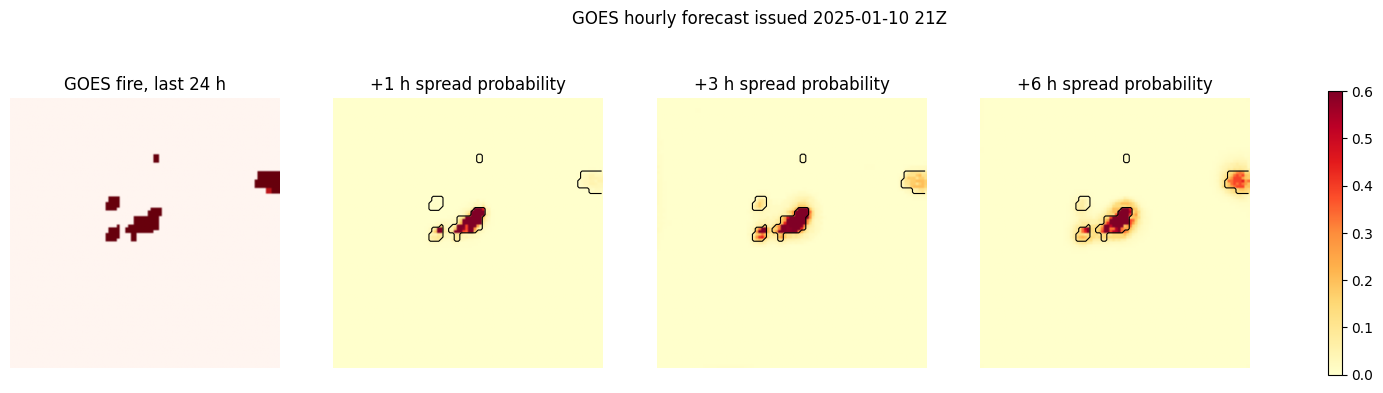

In [ ]:
if RUN_GOES_FORECAST:
    GOES_BUNDLES = {h: load_goes_bundle(h) for h in GOES_HORIZONS_H
                    if os.path.exists(os.path.join(BUNDLE_DIR, f'goes_h{h}', 'model.keras'))}
    assert GOES_BUNDLES, 'No GOES bundles yet: run Sections 19 and 20 first'
    _phi = PHI if (RUN_EVENT and 'PHI' in globals()) else None
    _bounds = PINN_BOUNDS if _phi else None
    GX, GOES_BURNED, GOES_OUT = goes_forecast(GOES_GRID, GOES_T, GOES_BUNDLES, _phi, _bounds)
    GOES_PATHS = {}
    for h, (p_u, p_p, p_f) in GOES_OUT.items():
        thr = GOES_BUNDLES[h]['thresholds']
        fc = to_geojson(p_f, GOES_GRID, GOES_T.strftime('%Y-%m-%dT%H:%M:%SZ'), thr, burned=GOES_BURNED,
                        extra_layers={'p_unet': p_u, 'p_pinn': p_p},
                        collection_props={'valid_time': (GOES_T + pd.Timedelta(hours=h)).strftime('%Y-%m-%dT%H:%M:%SZ'),
                                          'horizon_hours': h, 'layer': 'spread_risk',
                                          'model_version': GOES_BUNDLES[h]['manifest']['model_version'],
                                          'members': ['unet-goes'] + (['pinn'] if p_p is not None else []),
                                          'risk_thresholds': thr})
        validate_feature_collection(fc)
        GOES_PATHS[h] = os.path.join(OUTPUT_DIR, f'spread_goes_{GOES_T:%Y%m%dT%H}Z_h{h}.geojson')
        json.dump(fc, open(GOES_PATHS[h], 'w'))
        labs = pd.Series([f['properties']['risk_label'] for f in fc['features']]).value_counts().to_dict()
        print(f'+{h} h: {len(fc["features"])} features {labs} → {GOES_PATHS[h]}')

    # Scoring only, when the future is already in the archive
    if GOES_T + pd.Timedelta(hours=max(GOES_OUT)) < pd.Timestamp.now('UTC'):
        fconf, fnval, _ = goes_aws_hourly(GOES_GRID, GOES_T, max(GOES_OUT))
        prev = GX[..., 0]
        rows = []
        for h, (p_u, p_p, p_f) in GOES_OUT.items():
            y = make_label(*window(fconf, fnval, 0, h))
            for sname, sub in [('all', None), ('new fire', prev == 0)]:
                rows.append({'horizon_h': h, 'pixels': sname,
                             **score(y, p_f, GOES_BUNDLES[h]['thresholds']['HIGH_RISK'], sub)})
        GOES_EVENT_SCORES = pd.DataFrame(rows)
        display(GOES_EVENT_SCORES[['horizon_h', 'pixels', 'n_pos', 'precision', 'recall', 'f1'] +
                                  [c_ for c_ in ('pr_auc',) if c_ in GOES_EVENT_SCORES]].round(3))

    fig, axes = plt.subplots(1, len(GOES_OUT) + 1, figsize=(5 * (len(GOES_OUT) + 1), 4.6))
    axes[0].imshow(GX[..., 2], cmap='Reds', vmin=0, vmax=1); axes[0].set_title('GOES fire, last 24 h')
    for ax, (h, (_, _, p_f)) in zip(axes[1:], GOES_OUT.items()):
        im = ax.imshow(p_f, cmap='YlOrRd', vmin=0, vmax=P_MAX); ax.set_title(f'+{h} h spread probability')
        ax.contour(GOES_BURNED, levels=[0.5], colors='k', linewidths=0.8)
    for ax in axes: ax.axis('off')
    fig.colorbar(im, ax=axes, shrink=0.8); plt.suptitle(f'GOES hourly forecast issued {GOES_T:%Y-%m-%d %H}Z'); plt.show()

---
## 22. Credentials, data sources and outputs

| Needed for | What | Where it is set |
|---|---|---|
| Live event inputs (11), Part B build (19), terrain/NDVI (21) | **Earth Engine** account + Cloud project | `EE_PROJECT` and the login cell under Section 1 |
| Fire detections for the daily model (11) | **FIRMS MAP_KEY** (free) | `FIRMS_MAP_KEY` |
| GOES-18 live / event data (18, 21) | Nothing: public NOAA bucket, anonymous HTTPS | — |
| Live hourly weather (21) | Nothing: Open-Meteo free tier, no key (non-commercial use) | — |
| Fire list for training (19) | MTBS through Earth Engine (same login) | — |

**Files written to `outputs_v3/`:** `current_fire_goes18_<time>.geojson`, `spread_goes_<time>_h1/h3/h6.geojson`,
`goes_h*_test_table.csv`, plus Part A's NetCDF and `+24 h` GeoJSON. Bundles: `unet_bundle_v3/goes_h1`, `goes_h3`, `goes_h6`.

---
## Appendix A — Feature ablation (validation only)
Evidence for the channel choice in Section 5. Compares the 12 raw channels, the chosen 13 channels, and the old 23-channel
"all engineered" set (old cells [46], [56]). **Scored on validation**; the test set is not used. Differences smaller than the
seed-to-seed spread are noise.

In [ ]:
_OFFSETS = [(dr, dc) for dr in (-1, 0, 1) for dc in (-1, 0, 1) if (dr, dc) != (0, 0)]
_K = np.zeros((3, 3, 1, 8), np.float32)
for _k, (_dr, _dc) in enumerate(_OFFSETS):
    _K[1 + _dr, 1 + _dc, 0, _k] = 1.0
_NEIGHBOUR_KERNEL = tf.constant(_K)
_DISP = np.array([(-dc, dr) for dr, dc in _OFFSETS], np.float32)
_DISP /= np.linalg.norm(_DISP, axis=1, keepdims=True)
_DISP_E, _DISP_N = tf.constant(_DISP[:, 0]), tf.constant(_DISP[:, 1])
_img = lambda x: x[None, :, :, None]
_unimg = lambda x: x[0, :, :, 0]
KM = 1000.0


def engineer_full(fd):
    """Old cell [46], unchanged in substance: all 12 engineered features."""
    out = add_wind_uv(fd)
    z, vs, u, v = fd['elevation'], fd['vs'], out['wind_u'], out['wind_v']
    zp = _unimg(tf.pad(_img(z), [[0, 0], [1, 1], [1, 1], [0, 0]], mode='SYMMETRIC'))
    dzdx = (zp[1:-1, 2:] - zp[1:-1, :-2]) / (2 * KM)
    dzdy = (zp[:-2, 1:-1] - zp[2:, 1:-1]) / (2 * KM)
    out['slope'] = tf.atan(tf.sqrt(dzdx ** 2 + dzdy ** 2)) * (180.0 / math.pi)
    aspect = tf.atan2(-dzdx, -dzdy)
    out['aspect_sin'], out['aspect_cos'] = tf.sin(aspect), tf.cos(aspect)
    out['upslope_wind'] = u * dzdx + v * dzdy
    t_c = fd['tmmx'] - 273.15
    p_pa = 101325.0 * tf.pow(tf.maximum(1.0 - 2.25577e-5 * z, 0.1), 5.25588)
    q = tf.maximum(fd['sph'], 0.0)
    e = q * p_pa / (0.622 + 0.378 * q)
    es = 610.94 * tf.exp(17.625 * t_c / (t_c + 243.04))
    out['vpd_kpa'] = tf.maximum(es - e, 0.0) / 1000.0
    out['rh_min'] = tf.clip_by_value(100.0 * e / es, 0.0, 100.0)
    out['temp_range'] = fd['tmmx'] - fd['tmmn']
    prev = _img(tf.clip_by_value(fd['PrevFireMask'], 0.0, 1.0))
    out['fire_density'] = _unimg(tf.nn.avg_pool2d(prev, 5, 1, 'SAME'))
    d, dist = prev, tf.zeros_like(prev)
    for _ in range(MAX_FIRE_DIST_KM):
        dist += 1.0 - d
        d = tf.nn.max_pool2d(d, 3, 1, 'SAME')
    out['fire_dist'] = _unimg(dist)
    neigh = tf.nn.conv2d(prev, _NEIGHBOUR_KERNEL, 1, 'SAME')[0]
    speed = tf.sqrt(u ** 2 + v ** 2) + 1e-6
    align = tf.nn.relu((u[..., None] * _DISP_E + v[..., None] * _DISP_N) / speed[..., None])
    out['downwind_fire'] = tf.reduce_sum(neigh * align, axis=-1) * tf.minimum(vs / 5.0, 2.0)
    return out


ENGINEERED_FULL = ['wind_u', 'wind_v', 'slope', 'aspect_sin', 'aspect_cos', 'upslope_wind',
                   'vpd_kpa', 'rh_min', 'temp_range', 'fire_density', 'fire_dist', 'downwind_fire']

if RUN_ABLATION:
    ABL_STATS = load_or_compute_stats(os.path.join(DATA_ROOT, 'feature_stats_v3_ablation.json'),
                                      RAW_INPUTS + ENGINEERED_FULL, engineer_full)
    ABLATION = {
        '12 raw (th as angle)':        RAW_INPUTS + ['PrevFireMask'],
        '13: wind u/v (chosen)':       FEATURES,
        '23: all engineered (old)':    [f for f in RAW_INPUTS if f != 'th'] + ['PrevFireMask'] + ENGINEERED_FULL,
    }
    abl_rows = []
    for name, feats in ABLATION.items():
        for seed in SEEDS[:2]:
            mdl, _ = train_one(seed, feats, ABL_STATS, engineer_full, tag=f'abl{len(feats)}')
            yv, pv, prv = collect(mdl, build_dataset(EVAL_PATTERN, feats, ABL_STATS, False, engineer_full),
                                  feats.index('PrevFireMask'))
            m_all, m_new = yv >= 0, (yv >= 0) & (prv == 0)
            abl_rows.append({'config': name, 'seed': seed, 'channels': len(feats),
                             'val PR-AUC': average_precision_score(yv[m_all] == 1, pv[m_all]),
                             'val new-fire PR-AUC': average_precision_score(yv[m_new] == 1, pv[m_new])})
    ABL = pd.DataFrame(abl_rows)
    display(ABL.groupby(['config', 'channels'])[['val PR-AUC', 'val new-fire PR-AUC']].agg(['mean', 'std']).round(4))
    ABL.to_csv(os.path.join(OUTPUT_DIR, 'ablation_validation.csv'), index=False)

## Appendix B — Permutation importance (validation only)
From old cell [58], now on validation and on the shipped 13-channel model. A channel is shuffled across tiles in a batch;
the drop in PR-AUC measures reliance on it. Correlated channels share credit.

In [ ]:
def permutation_importance(model, features, stats, max_batches=40):
    base_ds = build_dataset(EVAL_PATTERN, features, stats, False).take(max_batches)
    prev_idx = features.index('PrevFireMask')
    y, p, _ = collect(model, base_ds, prev_idx)
    m = y >= 0
    base_ap = average_precision_score(y[m] == 1, p[m])
    rows = []
    for c, f in enumerate(features):
        def shuffle_channel(x, yy, c=c):
            idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
            col = tf.gather(x[..., c], idx)
            return tf.concat([x[..., :c], col[..., None], x[..., c + 1:]], axis=-1), yy
        yp, pp, _ = collect(model, base_ds.map(shuffle_channel), prev_idx)
        mm = yp >= 0
        rows.append({'feature': f, 'pr_auc_drop': base_ap - average_precision_score(yp[mm] == 1, pp[mm])})
    return pd.DataFrame(rows).sort_values('pr_auc_drop', ascending=False)


if RUN_PERM_IMPORTANCE:
    tf.random.set_seed(0)
    IMP = permutation_importance(best_model, FEATURES, STATS, max_batches=5 if SMOKE_TEST else 40)
    IMP.plot.barh(x='feature', y='pr_auc_drop', figsize=(7, 6), legend=False)
    plt.gca().invert_yaxis(); plt.title('Permutation importance on validation (PR-AUC drop)'); plt.tight_layout(); plt.show()

## Appendix C — Live-mode helpers (not used for evaluation)
For running on current fires rather than the evaluation event: recent FIRMS detections in California → DBSCAN clusters →
one lattice-snapped tile per cluster (from old cell [62]).

In [ ]:
from sklearn.cluster import DBSCAN


def find_fire_clusters(df, eps_km=5.0, min_points=5):
    if df.empty:
        return pd.DataFrame()
    labels = DBSCAN(eps=eps_km / 6371.0, min_samples=min_points, metric='haversine').fit_predict(
        np.radians(df[['latitude', 'longitude']].to_numpy()))
    d = df.assign(cluster=labels)
    d = d[d['cluster'] >= 0]
    return (d.groupby('cluster').agg(lat=('latitude', 'mean'), lon=('longitude', 'mean'),
                                     detections=('latitude', 'size'), total_frp=('frp', 'sum'))
             .sort_values('total_frp', ascending=False).reset_index())


# Example (needs FIRMS_MAP_KEY and Earth Engine):
# import ee; ee.Initialize(project=EE_PROJECT)
# day = (pd.Timestamp.now('UTC').normalize() - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
# clusters = find_fire_clusters(fetch_firms(day, 1, CA_BBOX, FIRMS_NRT_SOURCES))
# for c in clusters.head(3).itertuples():
#     g = Grid.around(c.lat, c.lon)
#     raw = gee_features(g, day); raw['PrevFireMask'] = rasterize_points(utc_day(dets, day), g)
#     p = predict_tile(BUNDLE, raw)   # → U-Net-only GeoJSON via to_geojson(p, g, ...)

---
## Summary
* **Daily model (Part A):** 13-channel U-Net → isotonic calibration (capped at `P_MAX`) → P(active fire in 1 km cell, next UTC
  day). Industrial heat sources filtered; per-cell `p_low`–`p_high` range from three seeds. Valid at +24 h only.
* **Hourly model (Part B):** same U-Net on GOES + RTMA samples from MTBS California fires, one bundle per horizon, run live
  from NOAA's GOES-18 bucket → `+1 / +3 / +6 h` GeoJSON, plus a model-free GOES "Current Fire Detection" layer.
* **Evidence:** Section 10 (daily) and Section 20 (hourly) report all-pixel and **new-fire** skill against persistence,
  dilation and distance decay. Use the new-fire comparison to decide how to describe each output.
* **Open decisions:** `team_discussion_points.txt` (grid, event, PINN units/sign/normalization, GeoJSON schema, thresholds).